# Week 2 Estimator Test Bench

Self-contained test harness for the latent/input Estimator_v2.

- **`simulator.py`** — simulation + plotting (replaces `SimulationIllustrationFuncs`).
- **`Fiana.py`** — your Estimator_v2 (`estimate_latent_and_input`).

Put all three files in the same folder and run top to bottom.
Each test case shows: (1) the ground-truth inputs/latents/observations, then
(2) your estimate (black = ground truth, colour = your estimate, aligned into
the true latent frame).

In [301]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import simulator
importlib.reload(simulator)
from simulator import (
    simulate,
    simulate_from_latents,
    fit_transform_latents,
    plot_input_latent_observation,
    plot_input_latent_comparison,
)

import Estimator_v2
importlib.reload(Estimator_v2)

%matplotlib inline

def run_Estimator_v2(observations, latent_dim, input_dim):
    """Call the Estimator_v2; if it rejects the case (e.g. LatentDim > #neurons),
    report it instead of crashing the whole notebook."""
    try:
        X_est, U_est = Estimator_v2.estimate_latent_and_input(
            np.asarray(observations),
            LatentDim=latent_dim,
            InputDim=input_dim,
        )
        return {"Estimator_v2": {"latent_states": X_est, "inputs": U_est}}
    except Exception as e:
        print(f"[Estimator_v2 skipped this case] {type(e).__name__}: {e}")
        return {}

print("Setup complete.")

Setup complete.


# Sparse Impulse Input

### Case 1

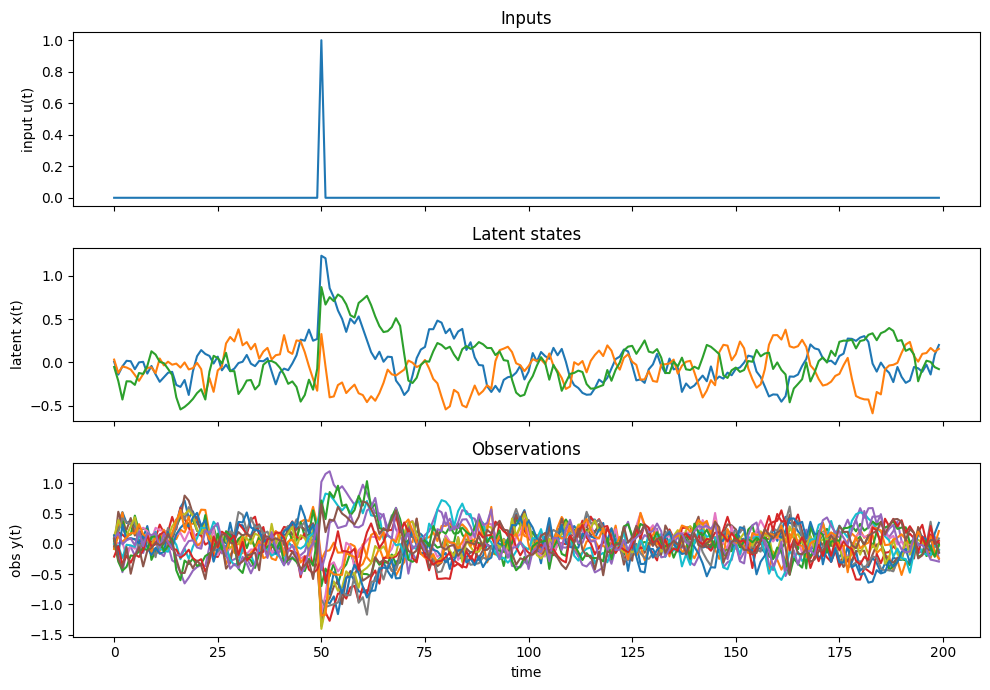

In [302]:
A = np.array([[0.9, 0.1, 0],
              [-0.2, 0.8, 0],
              [0.1, -0.1, 0.8]])
B = np.array([[1], [0.6], [0.8]])
C = np.random.normal(0, 1, (16, 3)); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((200, 1)); inputs[50] = 1
x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 0.1, (200, 16))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

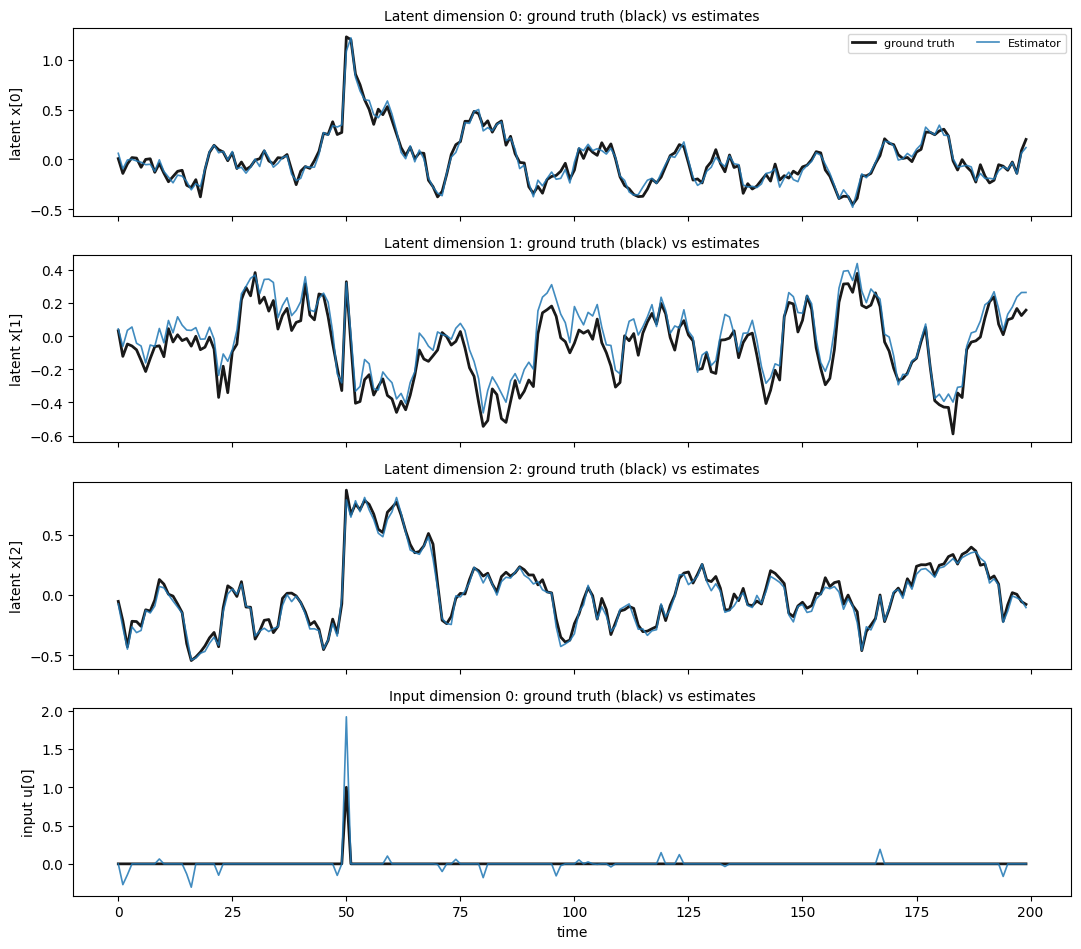

In [303]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 2 - null-space injection

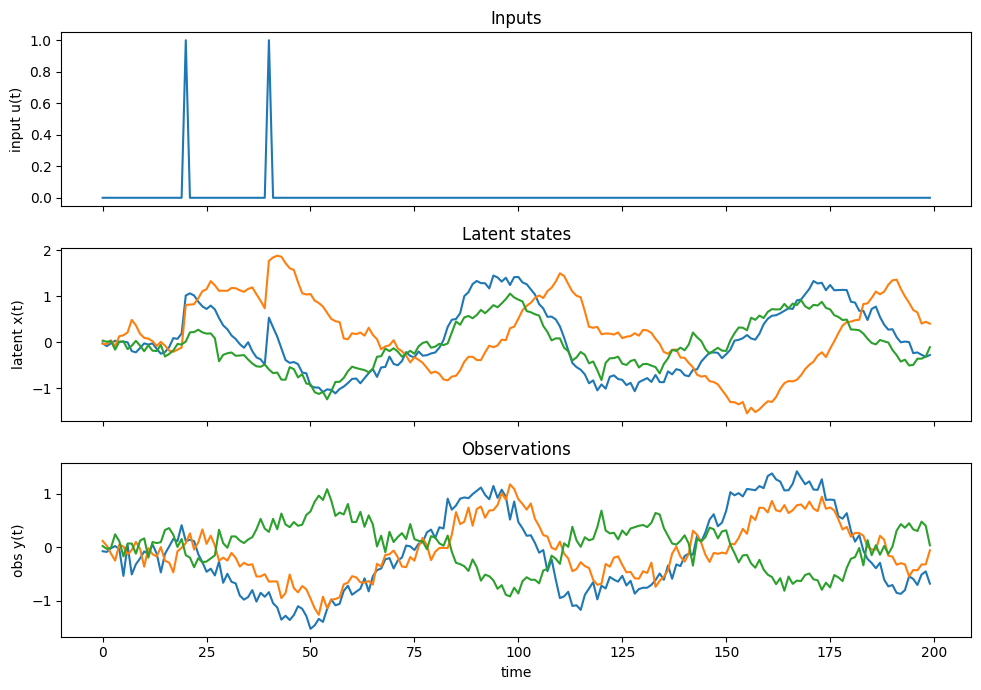

In [304]:
angle = 5 / 180 * np.pi
A = np.array([[np.cos(angle)*0.98, -np.sin(angle)*0.98, 0],
              [np.sin(angle)*0.98, np.cos(angle)*0.98, 0],
              [0.1, -0.1, 0.8]])
B = np.array([[1], [1], [0]])
C = np.array([[1, -1, 0], [0, 0, 1], [0.1, -0.098, -1]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((200, 1)); inputs[20] = 1; inputs[40] = 1
x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 0.1, (200, 3))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

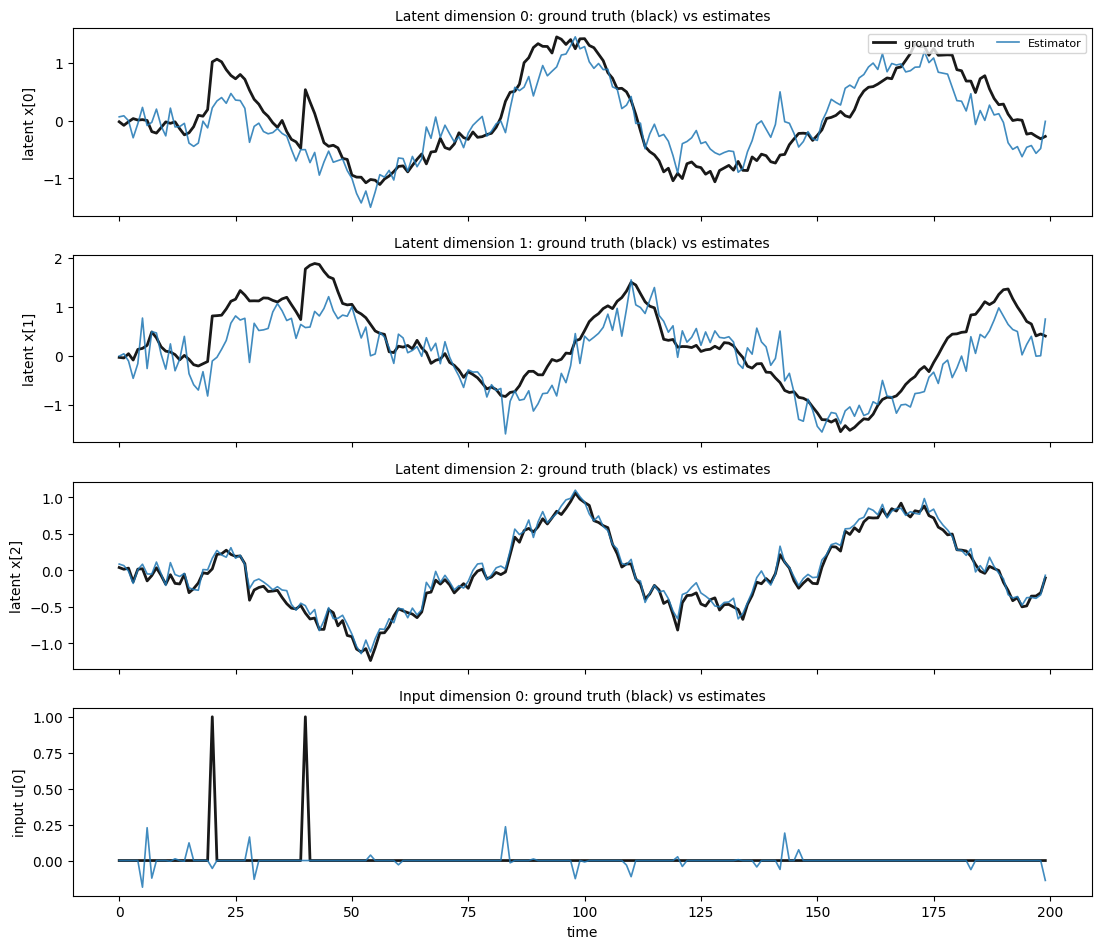

In [305]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 3 - null-space injection

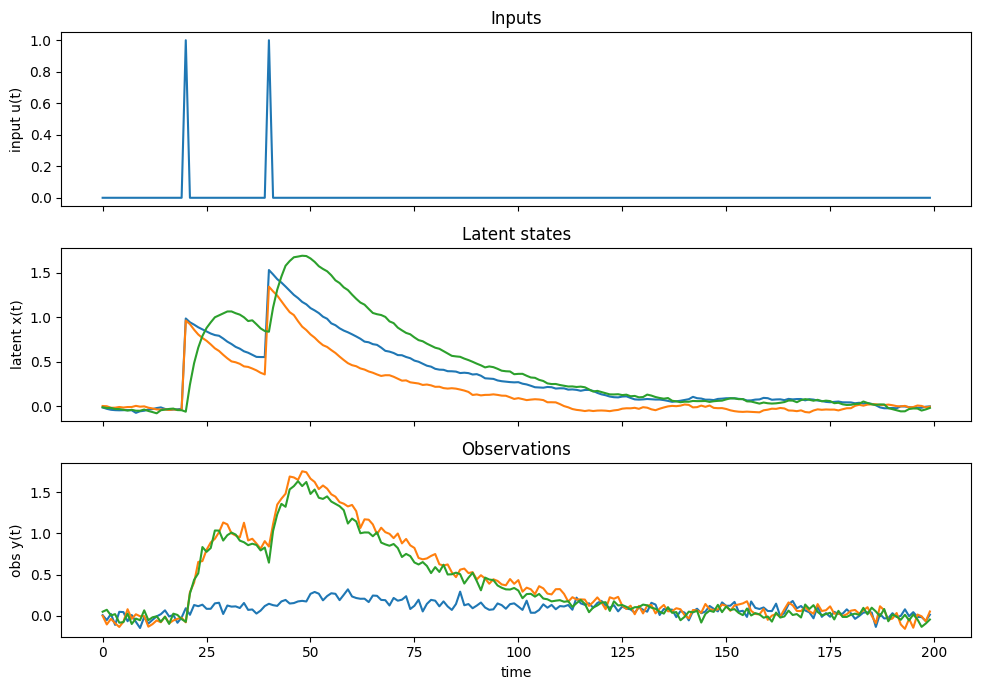

In [306]:
A = np.array([[0.97, 0, 0],
              [0, 0.95, 0],
              [0.2, 0.1, 0.8]])
B = np.array([[1], [1], [0]])
C = np.array([[1, -1, 0], [0.1, -0.1, 0.5], [-0.1, 0.09, 0.5]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((200, 1)); inputs[20] = 1; inputs[40] = 1
x_noise = np.random.normal(0, 0.01, (200, 3))
y_noise = np.random.normal(0, 0.05, (200, 3))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

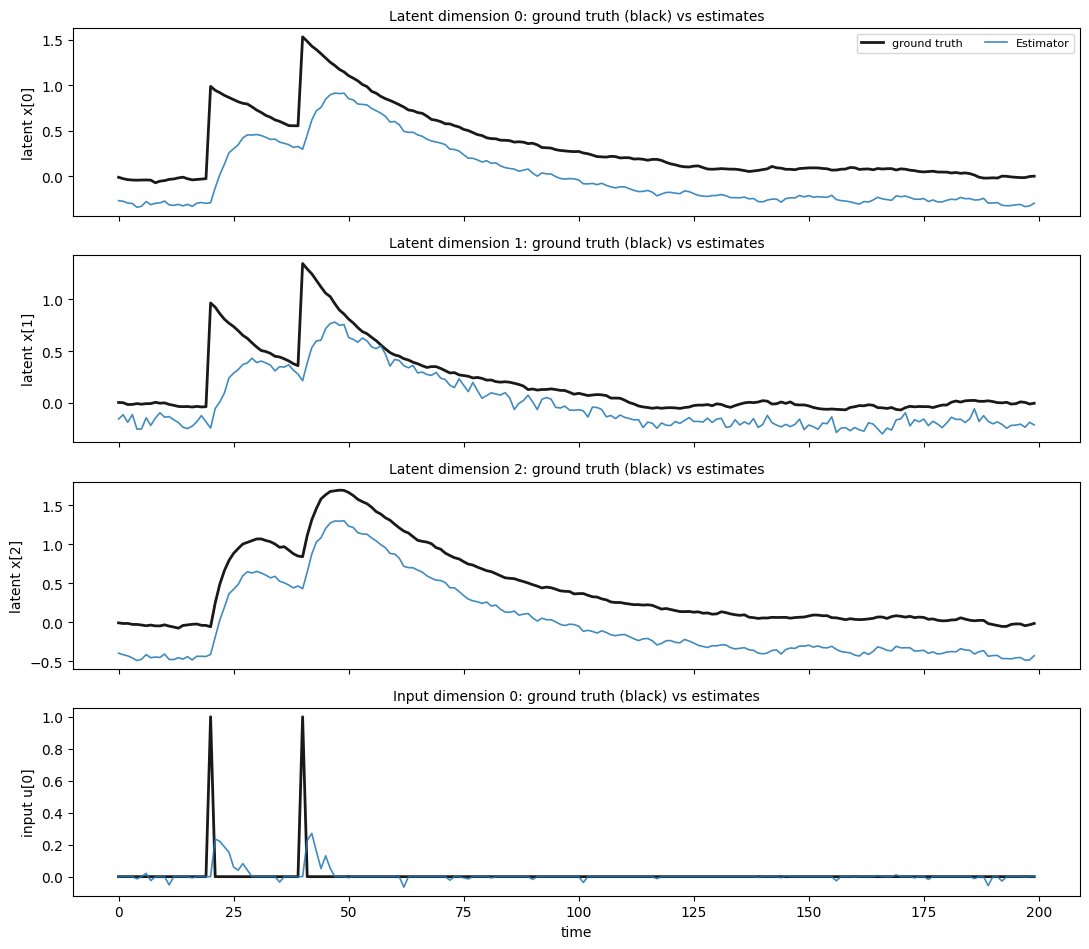

In [307]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 4 - ill-conditioned

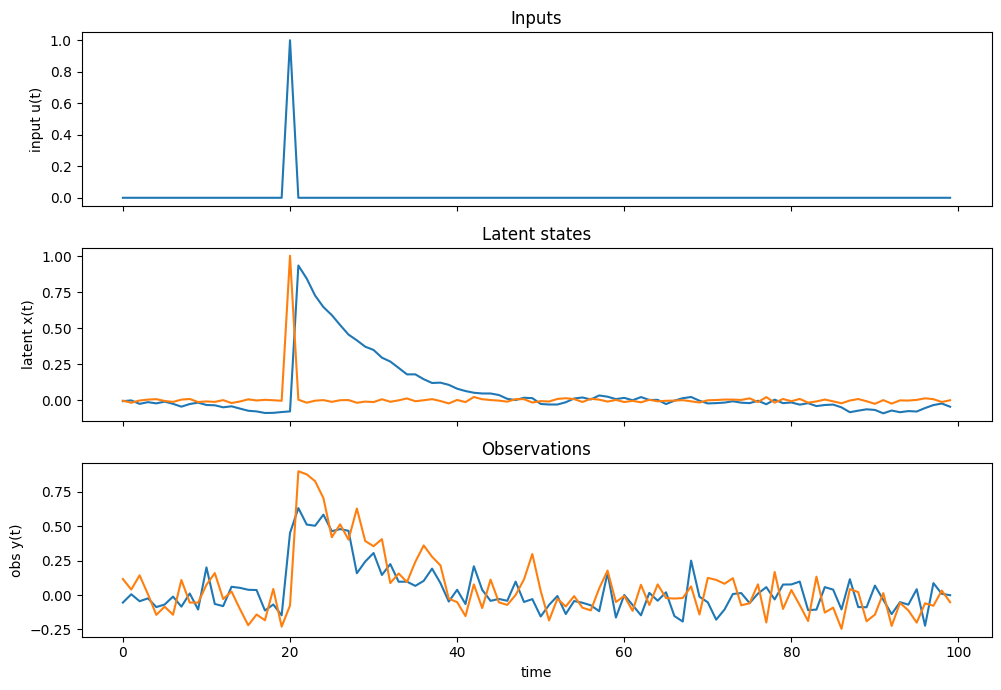

In [308]:
A = np.array([[0.9, 1], [0, 0.01]])
B = np.array([[0], [1]])
C = np.array([[1.0, 1.0], [1.0, 0.0]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[20] = 1
x_noise = np.random.normal(0, 0.01, (100, 2))
y_noise = np.random.normal(0, 0.1, (100, 2))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

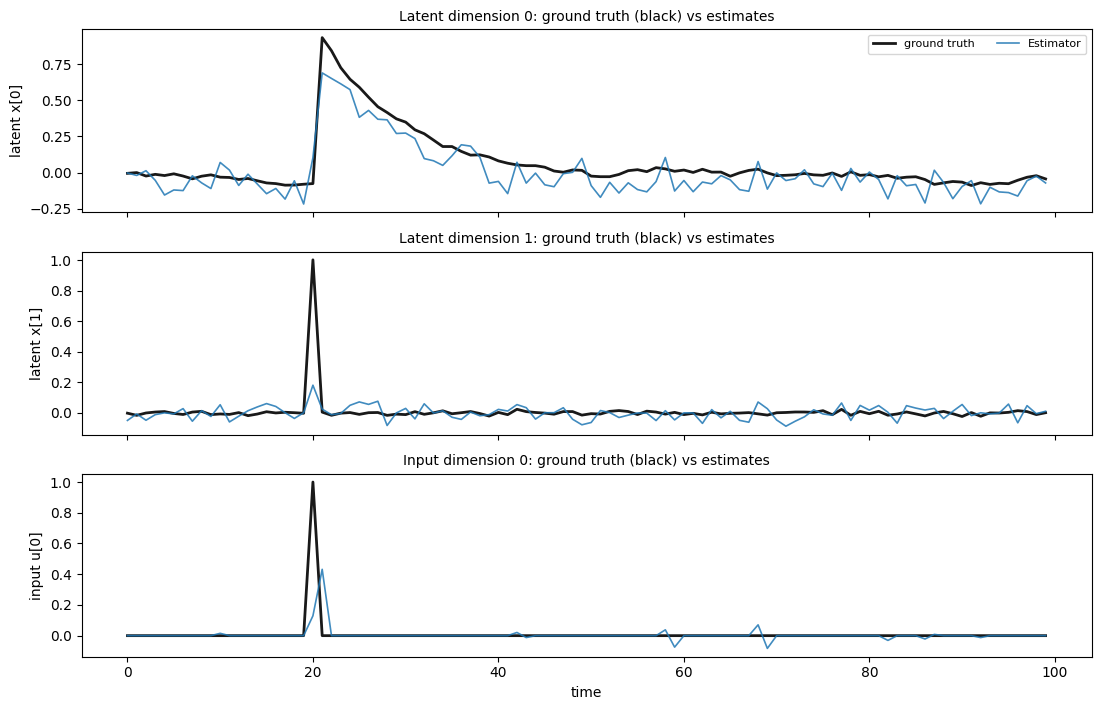

In [309]:
results = run_estimator(observations, latent_dim=2, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 5 - ill-conditioned

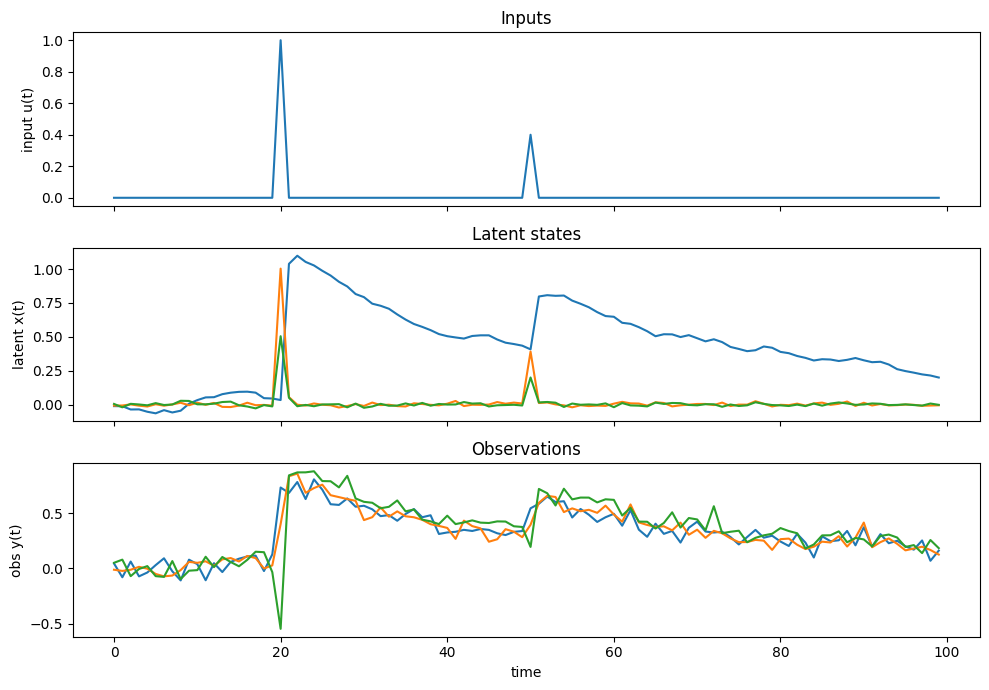

In [310]:
A = np.array([[0.97, 0.5, 1], [0, 0.05, 0], [0, 0, 0.1]])
B = np.array([[0], [1], [0.5]])
C = np.array([[1.0, 1.0, 0], [1.0, 0, 1.0], [1.0, -0.5, -0.5]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[20] = 1; inputs[50] = 0.4
x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.05, (100, 3))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

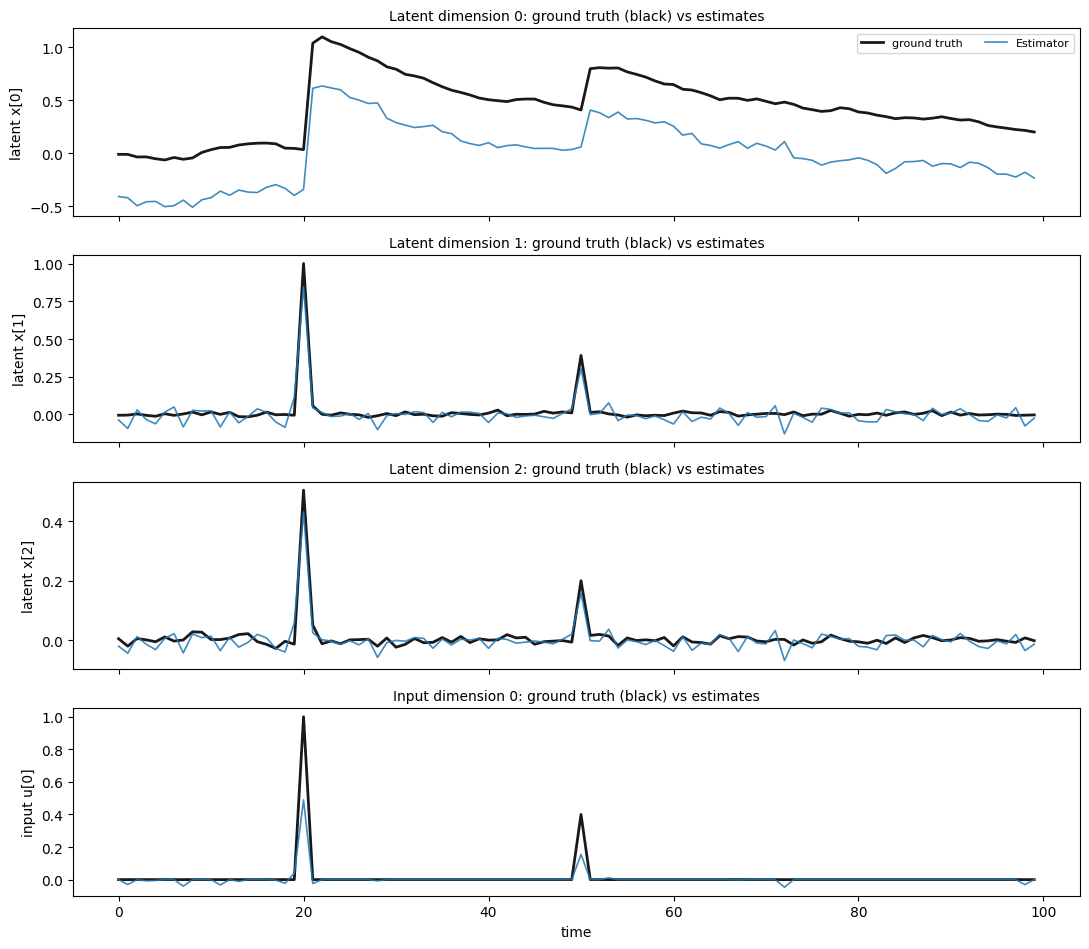

In [311]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 6 - transitional growth

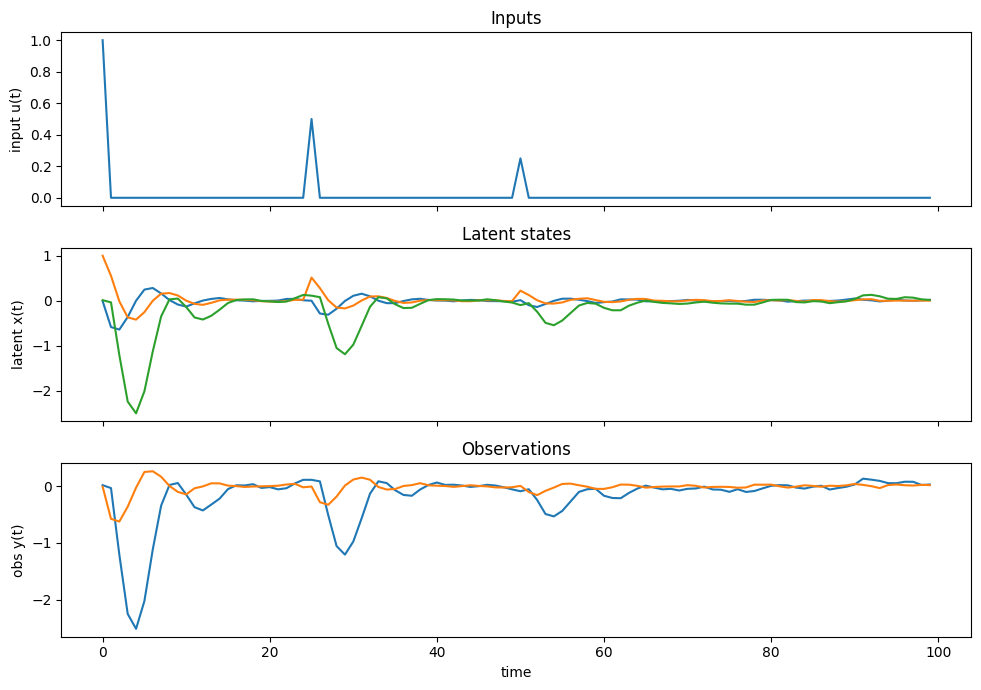

In [312]:
angle = 45 / 180 * np.pi
A = np.array([[0.8*np.cos(angle), -0.8*np.sin(angle), 0],
              [0.8*np.sin(angle), 0.8*np.cos(angle), 0],
              [2, 0, 0.8]])
B = np.array([[0], [1.0], [0]])
C = np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 0.0]])
inputs = np.zeros((100, 1)); inputs[0] = 1; inputs[25] = 0.5; inputs[50] = 0.25
x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.01, (100, 2))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

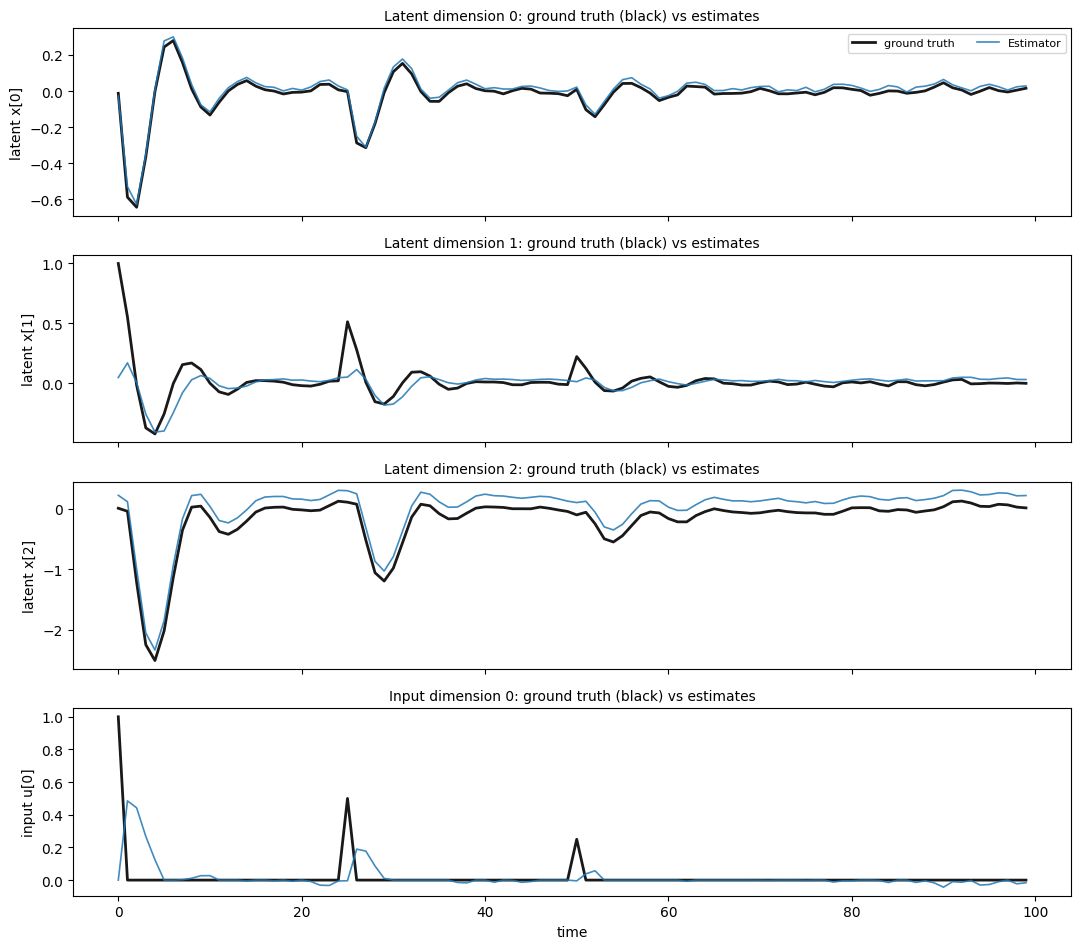

In [313]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 7 - hidden driven osc

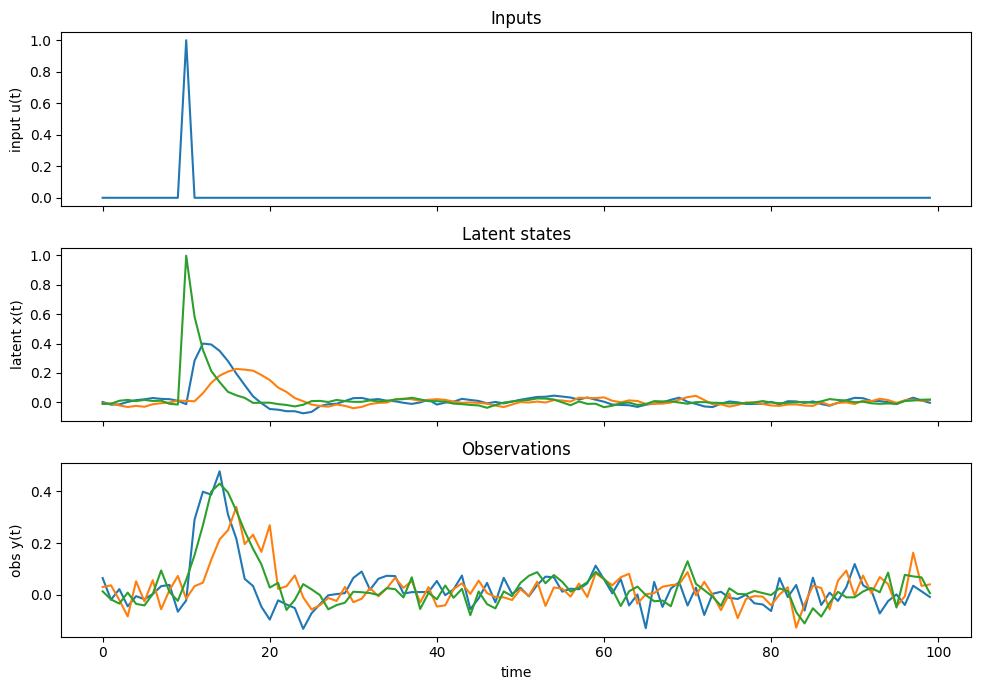

In [314]:
angle = 15 / 180 * np.pi
A = np.array([[0.8*np.cos(angle), -0.8*np.sin(angle), 0.3],
              [0.8*np.sin(angle), 0.8*np.cos(angle), 0],
              [0, 0, 0.6]])
B = np.array([[0.0], [0.0], [1.0]])
C = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.5, 0.5, 0.0]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[10] = 1
x_noise = np.random.normal(0, 0.01, (100, 3))
y_noise = np.random.normal(0, 0.04, (100, 3))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

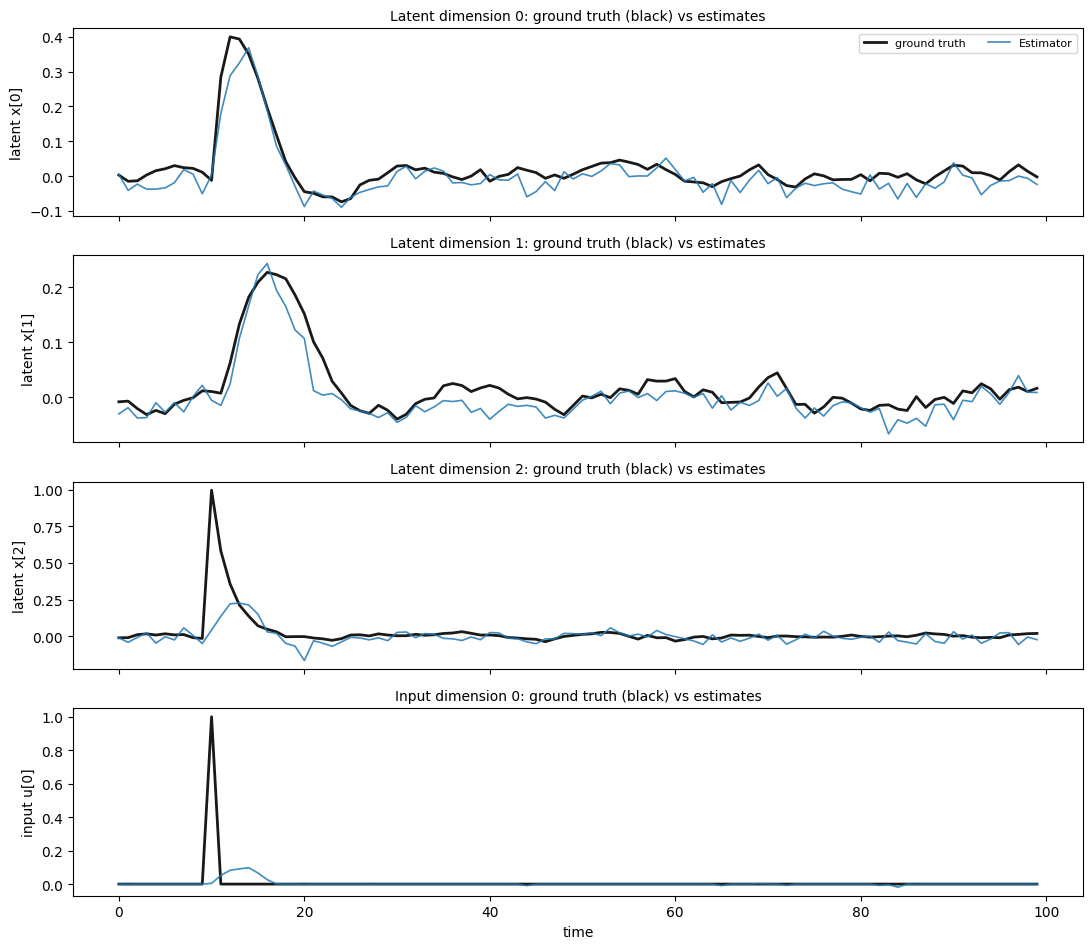

In [315]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 8 - High-low freq

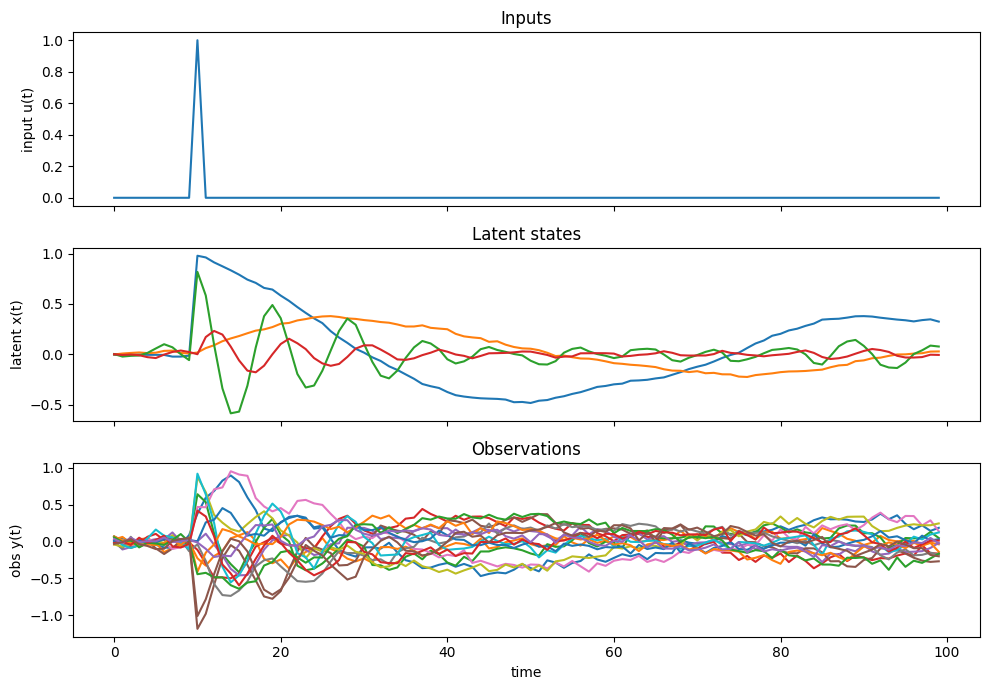

In [316]:
angle_slow = 4 / 180 * np.pi
angle_fast = 40 / 180 * np.pi
A = np.array([[0.98*np.cos(angle_slow), -0.98*np.sin(angle_slow)*2, 0, 0],
              [0.98*np.sin(angle_slow)/2, 0.98*np.cos(angle_slow), 0, 0],
              [0, 0, 0.95*np.cos(angle_fast), -0.95*np.sin(angle_fast)*3],
              [0, 0, 0.95*np.sin(angle_fast)/3, 0.95*np.cos(angle_fast)]])
B = np.array([[1], [0], [0.9], [0]])
C = np.random.normal(0, 1, (16, 4)); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[10] = 1
x_noise = np.random.normal(0, 0.01, (100, 4))
y_noise = np.random.normal(0, 0.04, (100, 16))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

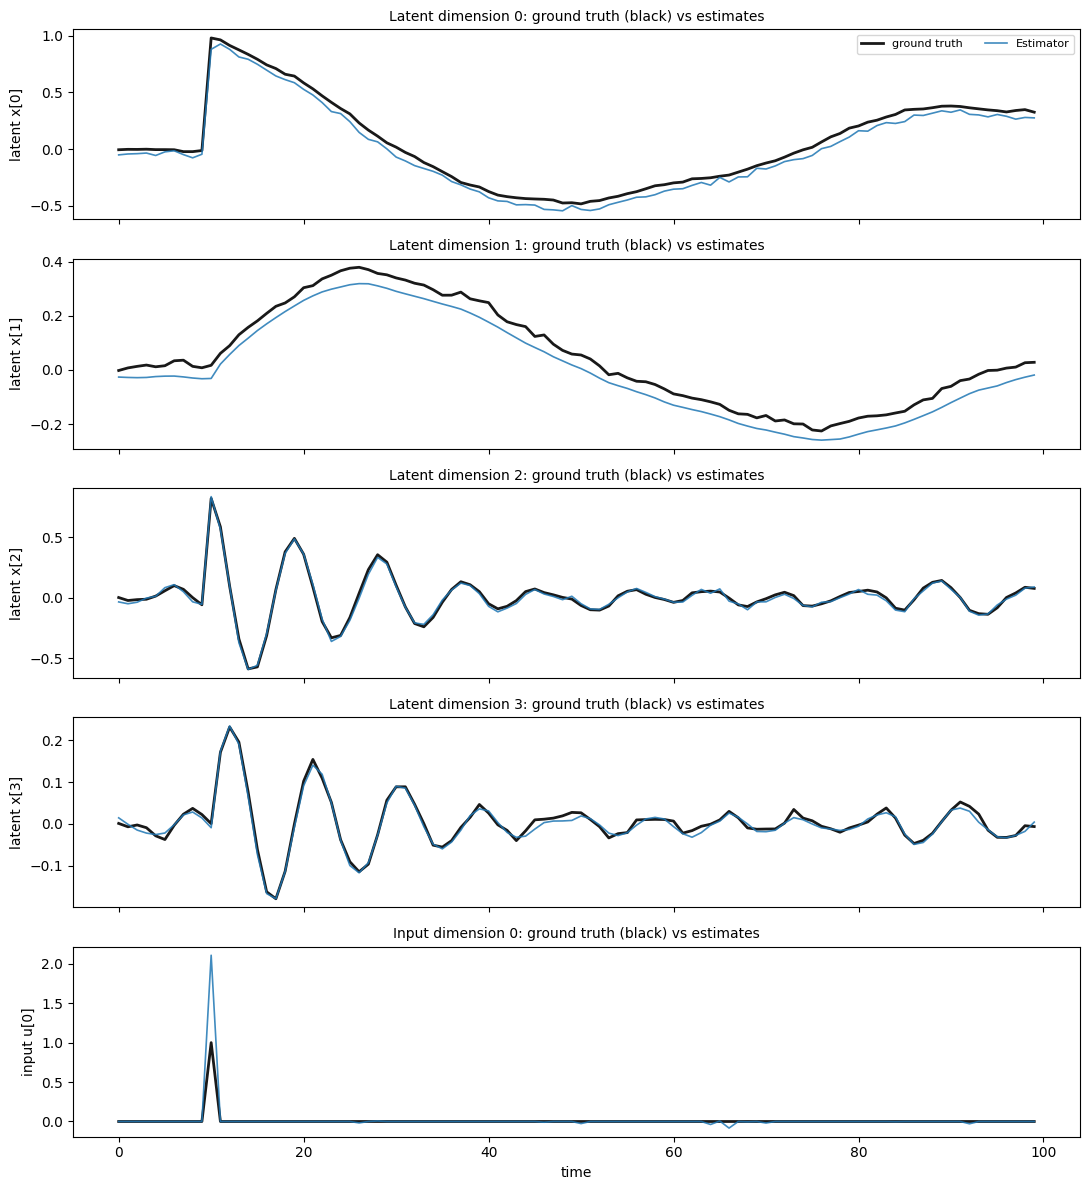

In [317]:
results = run_estimator(observations, latent_dim=4, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 9 - Noisy

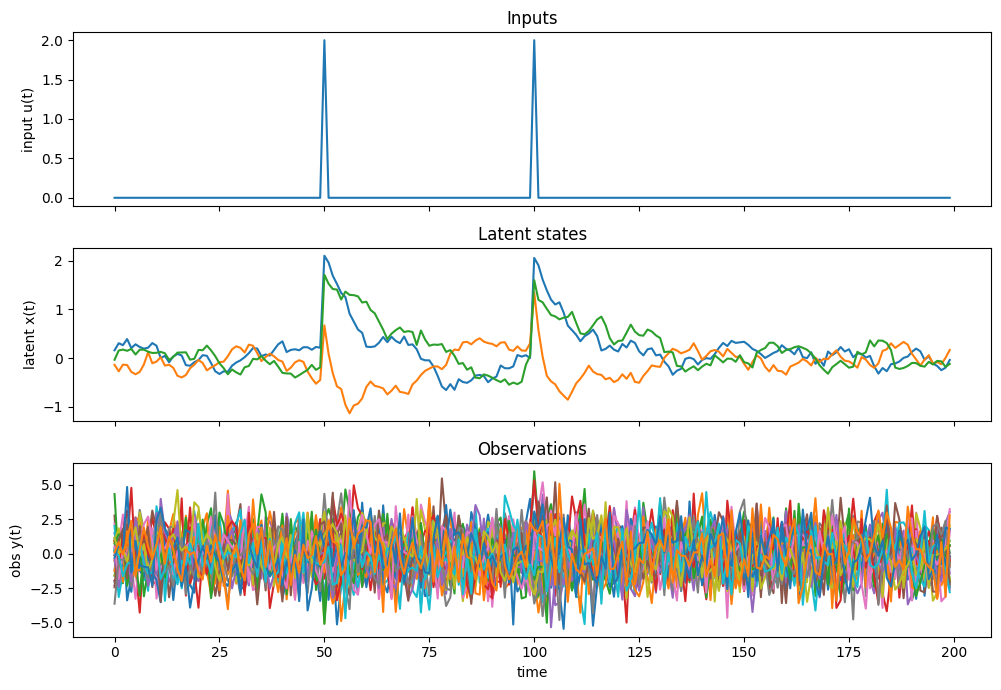

In [318]:
A = np.array([[0.9, 0.1, 0], [-0.2, 0.8, 0], [0.1, -0.1, 0.8]])
B = np.array([[1], [0.6], [0.8]])
C = np.random.normal(0, 1, (32, 3)); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((200, 1)); inputs[50] = 2; inputs[100] = 2
x_noise = np.random.normal(0, 0.1, (200, 3))
y_noise = np.random.normal(0, 1.5, (200, 32))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

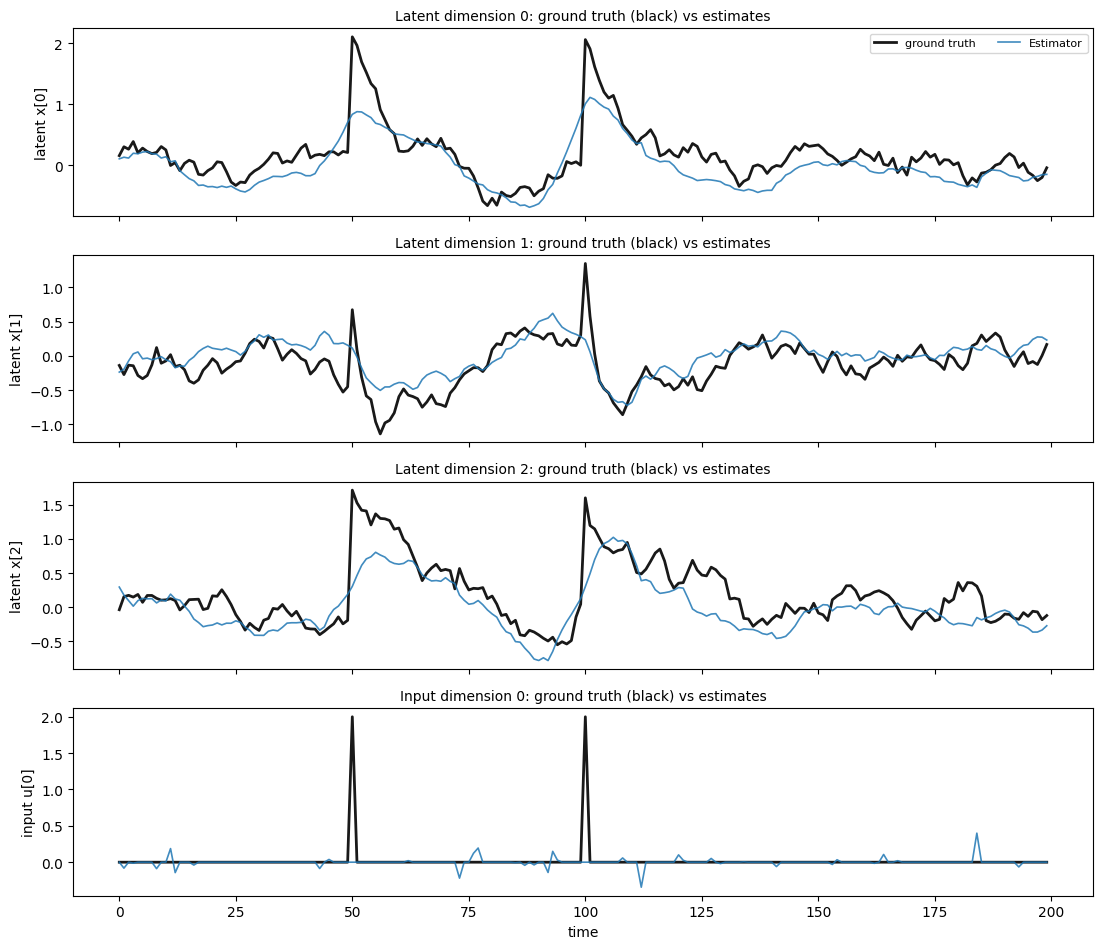

In [319]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 10 - Short Time

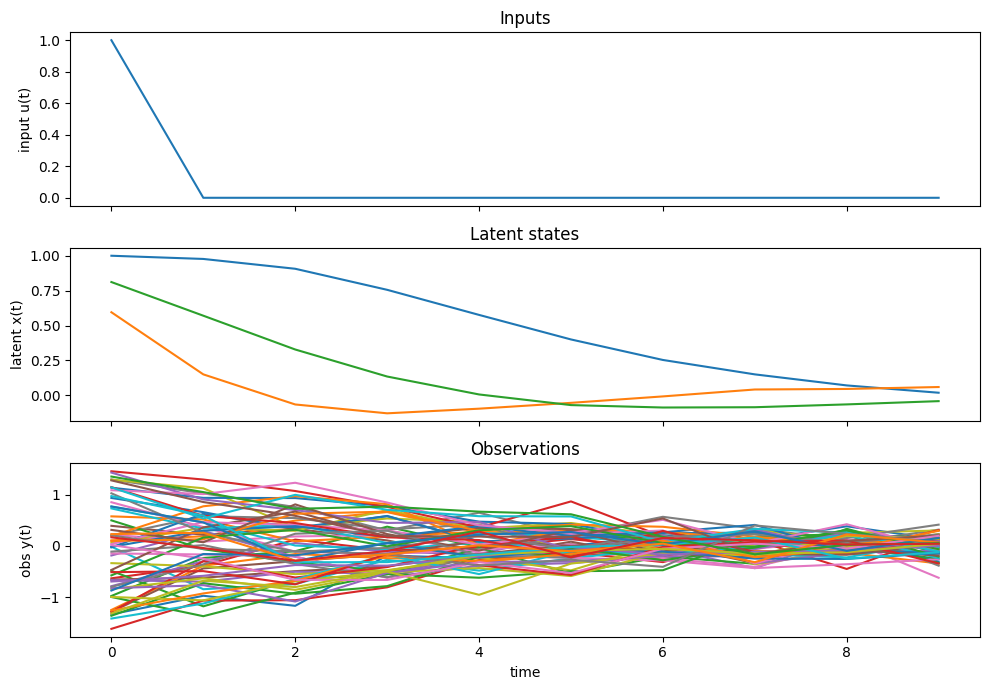

In [320]:
A = np.eye(3) * 0.7 + np.random.normal(0, 0.2, (3, 3))
B = np.array([[1], [0.6], [0.8]])
C = np.random.normal(0, 1, (64, 3)); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((10, 1)); inputs[0] = 1
x_noise = np.random.normal(0, 0.01, (10, 3))
y_noise = np.random.normal(0, 0.2, (10, 64))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

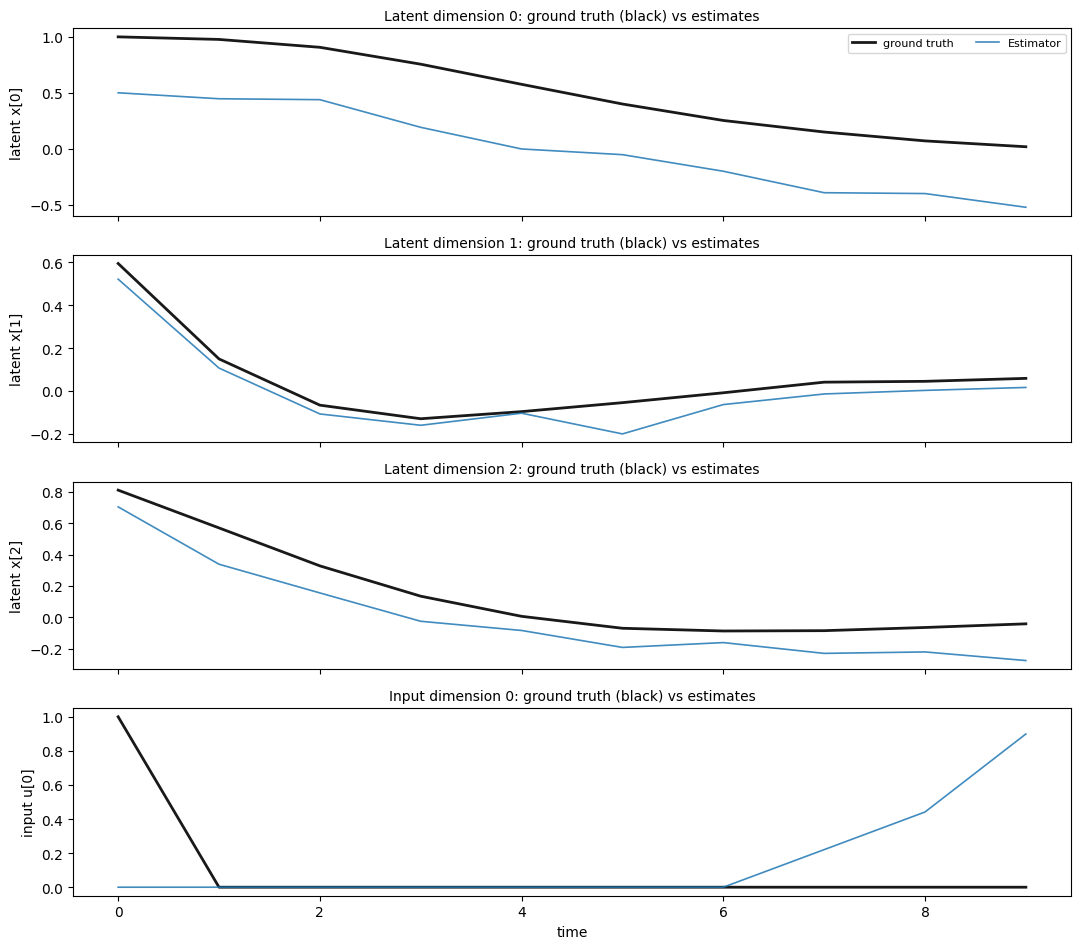

In [321]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 11 - Inadequate Latents (latent_dim=2 < true 4)

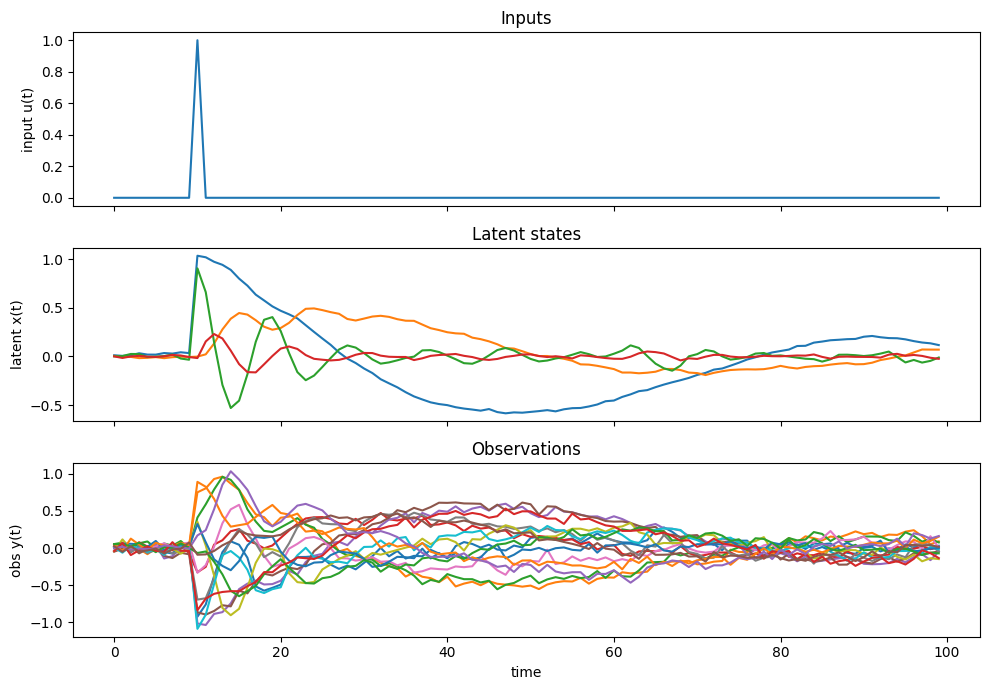

In [322]:
angle_slow = 4 / 180 * np.pi
angle_fast = 40 / 180 * np.pi
A = np.array([[0.98*np.cos(angle_slow), -0.98*np.sin(angle_slow)*2, 0, 0],
              [0.98*np.sin(angle_slow)/2, 0.98*np.cos(angle_slow), 0, 0.5],
              [0, 0, 0.9*np.cos(angle_fast), -0.9*np.sin(angle_fast)*3],
              [0, 0, 0.9*np.sin(angle_fast)/3, 0.9*np.cos(angle_fast)]])
B = np.array([[1], [0], [0.9], [0]])
C = np.random.normal(0, 1, (16, 4)); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[10] = 1
x_noise = np.random.normal(0, 0.01, (100, 4))
y_noise = np.random.normal(0, 0.04, (100, 16))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

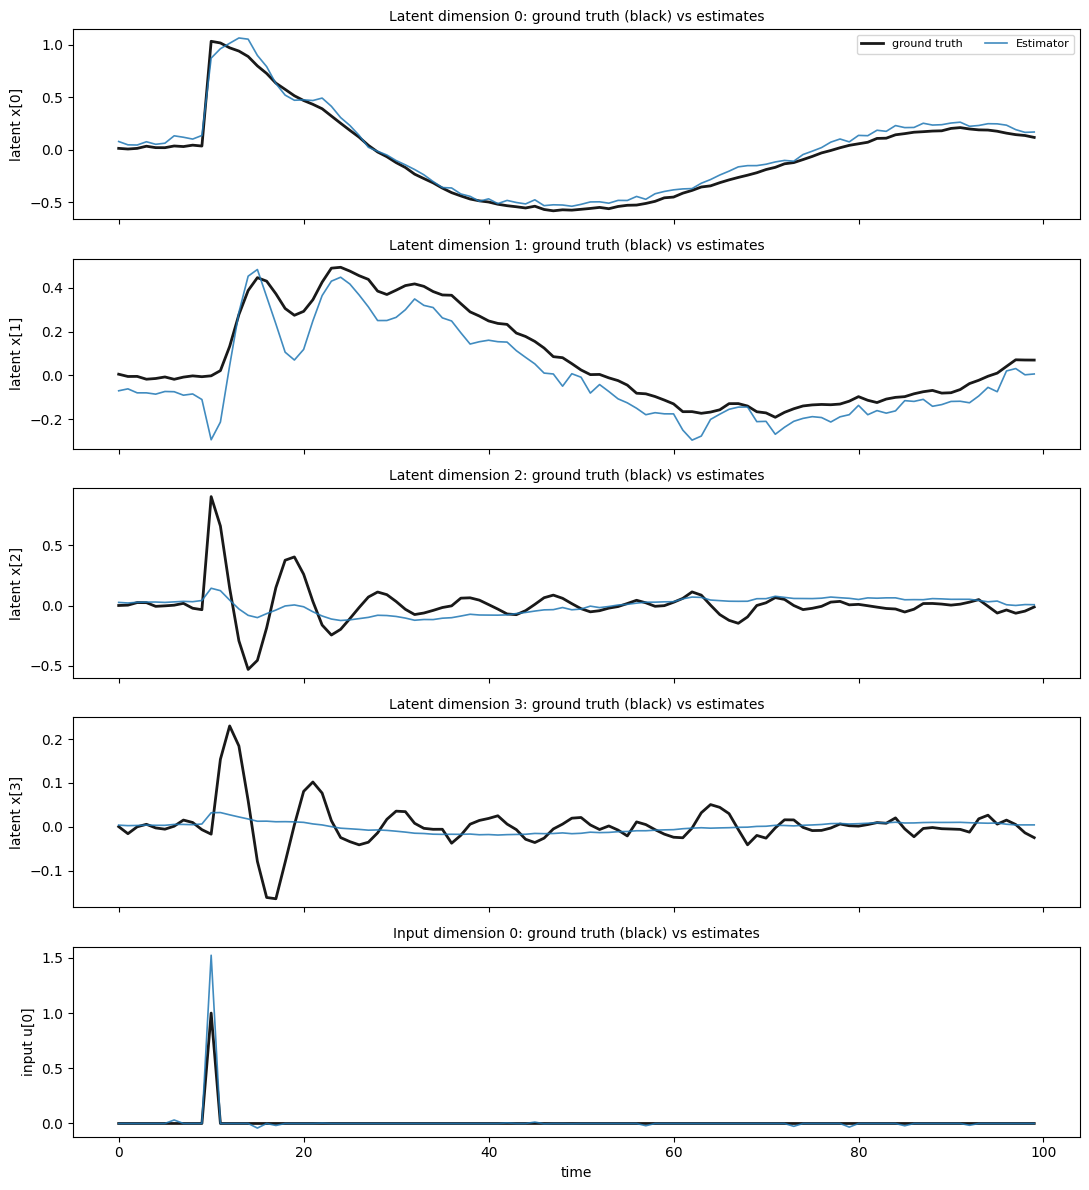

In [323]:
results = run_estimator(observations, latent_dim=2, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 12 - overcomplex assumption (latent_dim=8 > true 4)

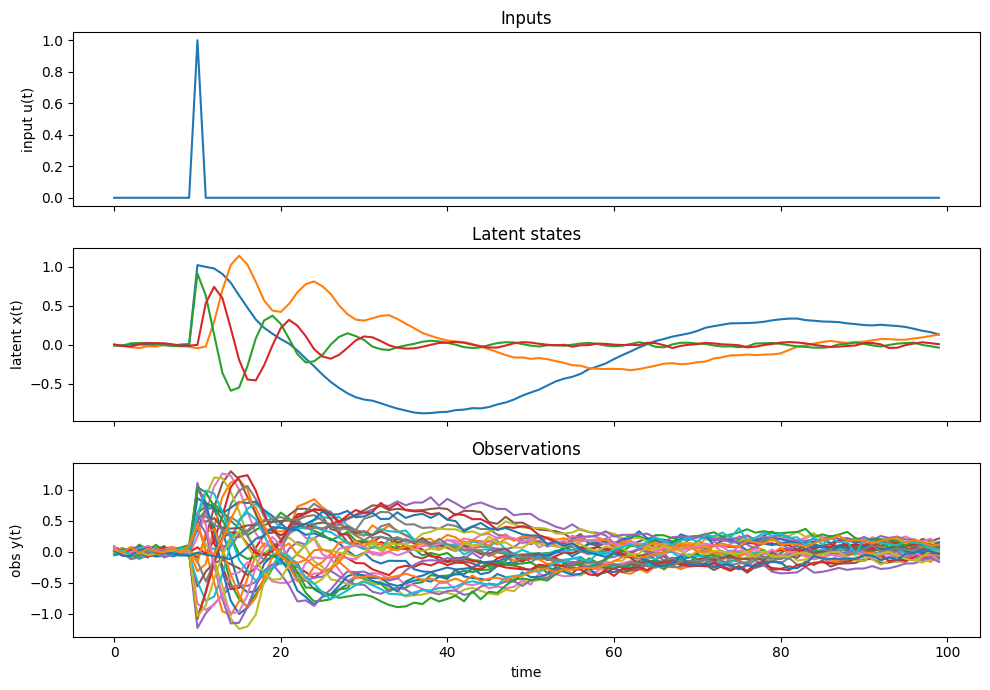

In [324]:
angle_slow = 4 / 180 * np.pi
angle_fast = 40 / 180 * np.pi
A = np.array([[0.98*np.cos(angle_slow), -0.98*np.sin(angle_slow)*2, 0, 0],
              [0.98*np.sin(angle_slow)/2, 0.98*np.cos(angle_slow), 0, 0.5],
              [0, 0, 0.9*np.cos(angle_fast), -0.9*np.sin(angle_fast)],
              [0, 0, 0.9*np.sin(angle_fast), 0.9*np.cos(angle_fast)]])
B = np.array([[1], [0], [0.9], [0]])
C = np.random.normal(0, 1, (32, 4)); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[10] = 1
x_noise = np.random.normal(0, 0.01, (100, 4))
y_noise = np.random.normal(0, 0.04, (100, 32))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

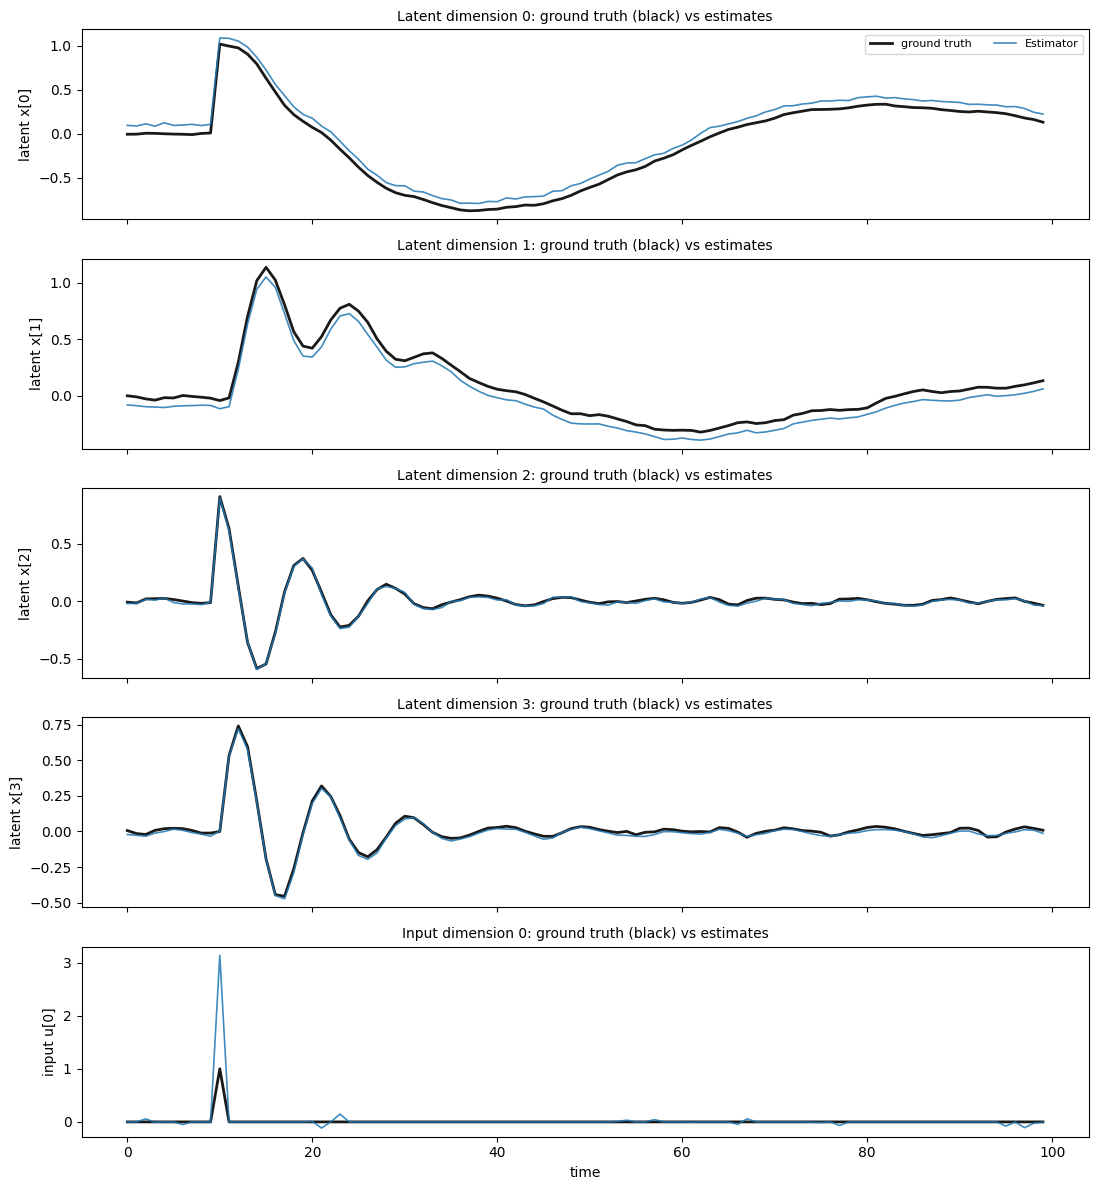

In [325]:
results = run_estimator(observations, latent_dim=8, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 13 - Low output dim

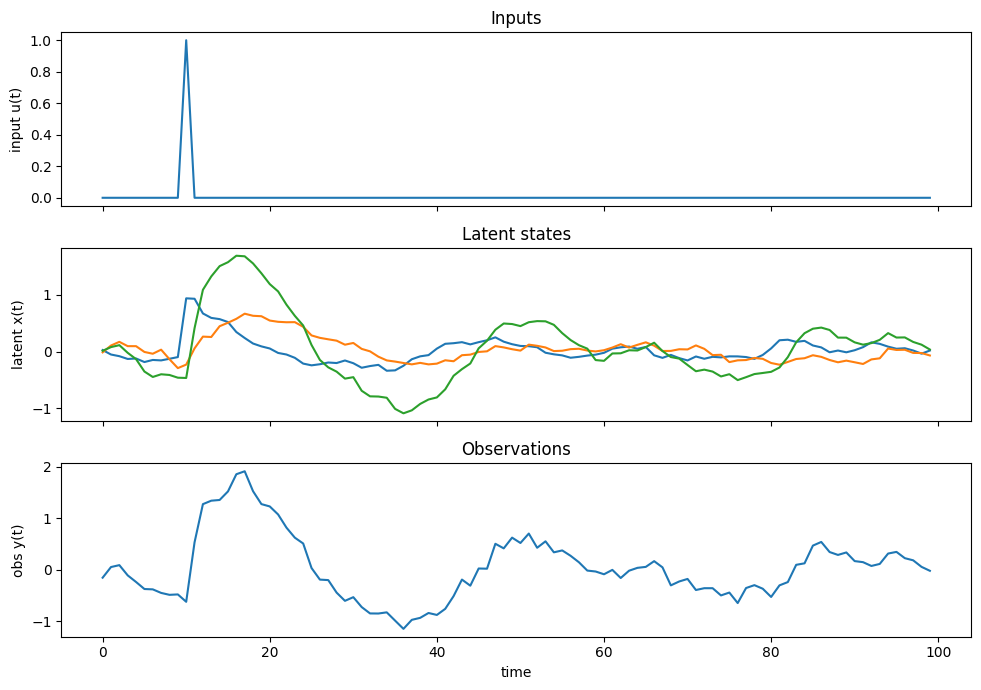

In [326]:
angle = 10 / 180 * np.pi
A = np.array([[0.95*np.cos(angle), -0.95*np.sin(angle)/1.5, 0],
              [0.95*np.sin(angle)*1.5, 0.90*np.cos(angle), 0],
              [0.8, 0, 0.8]])
B = np.array([[1.0], [0.0], [0.0]])
C = np.array([[0.0, 0.0, 1.0]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((100, 1)); inputs[10] = 1
x_noise = np.random.normal(0, 0.05, (100, 3))
y_noise = np.random.normal(0, 0.1, (100, 1))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

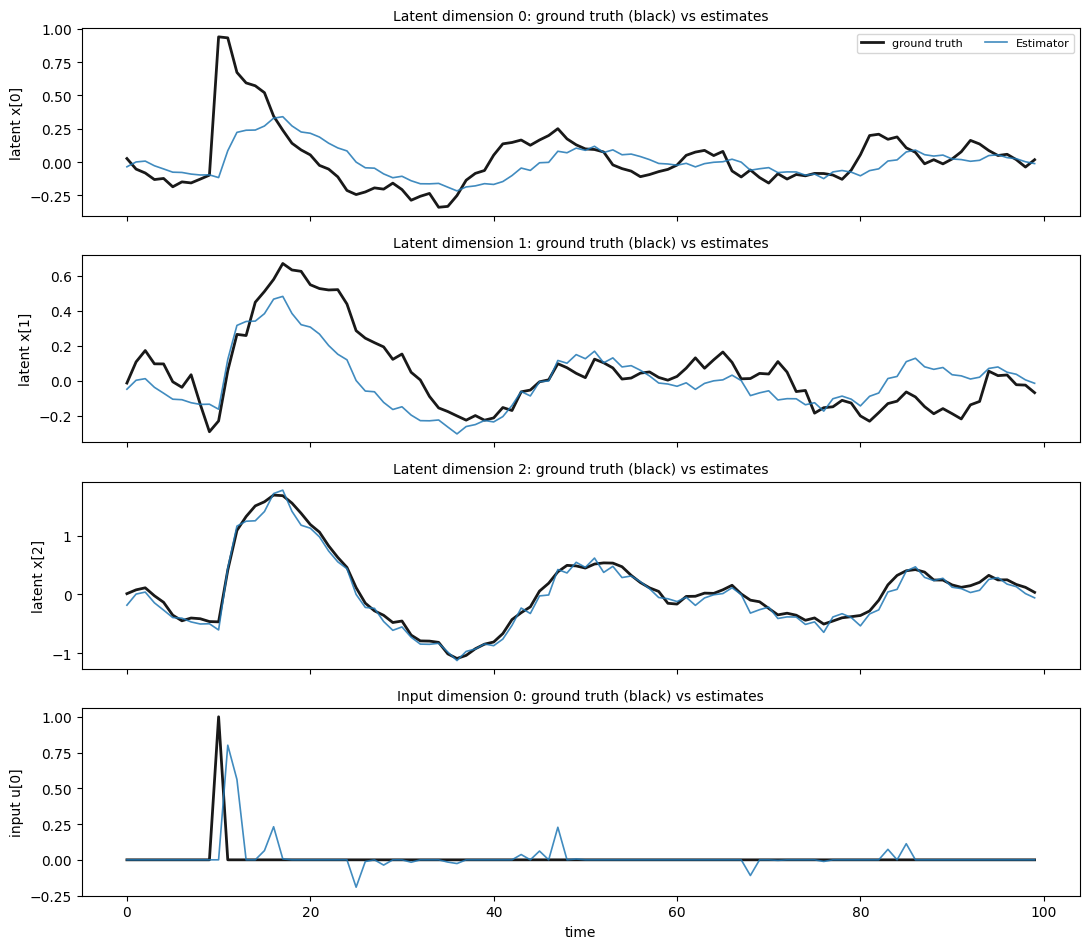

In [327]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 14 - No input, noise driven

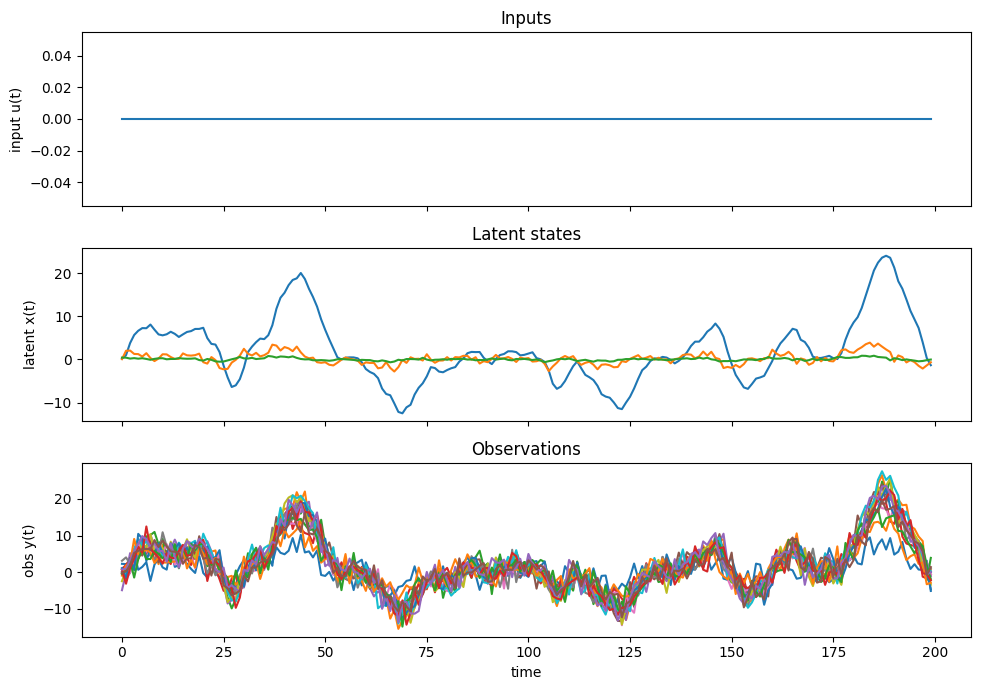

In [328]:
A = np.array([[0.85, 1, 2], [0, 0.1, 4], [0, 0, 0.8]])
B = np.array([[0], [0], [0.1]])
C = np.random.normal(0, 0.1, (16, 3))
C[:, 0] += np.abs(np.random.normal(0, 0.2, (16,))) + 0.1
C /= np.linalg.norm(C, axis=1, keepdims=True)
inputs = np.zeros((200, 1))
x_noise = np.random.normal(0, 0.2, (200, 3))
y_noise = np.random.normal(0, 2, (200, 16))
states, observations = simulate(A, B, C, inputs, x_noise, y_noise)

plot_input_latent_observation(inputs, states, observations)
plt.show()

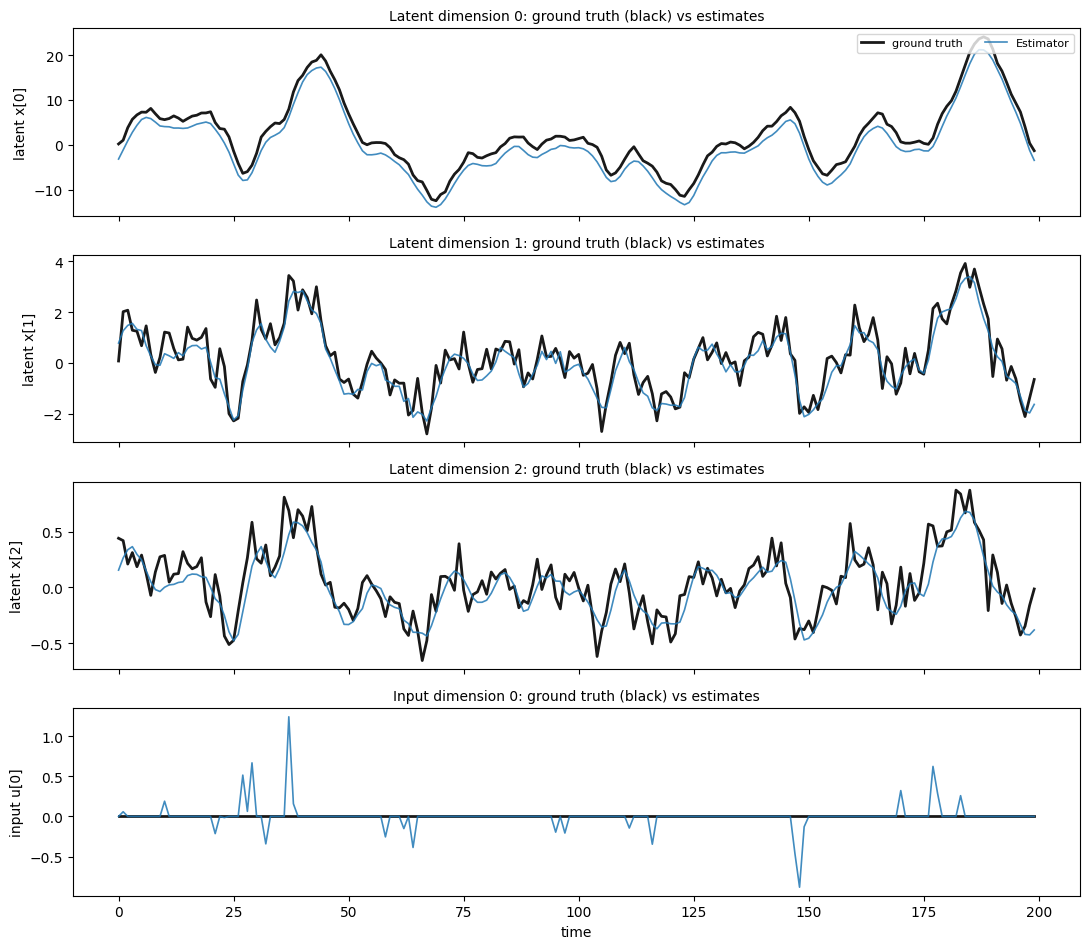

In [329]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

# Min-energy Input (waypoint-driven)

These use `simulate_from_latents`: an input sequence is *planned* (min-energy, multi-step) so chosen latent components hit target values at given times. The estimator then has to recover the latent trajectory from observations alone.

### Case 1 - null-space injection

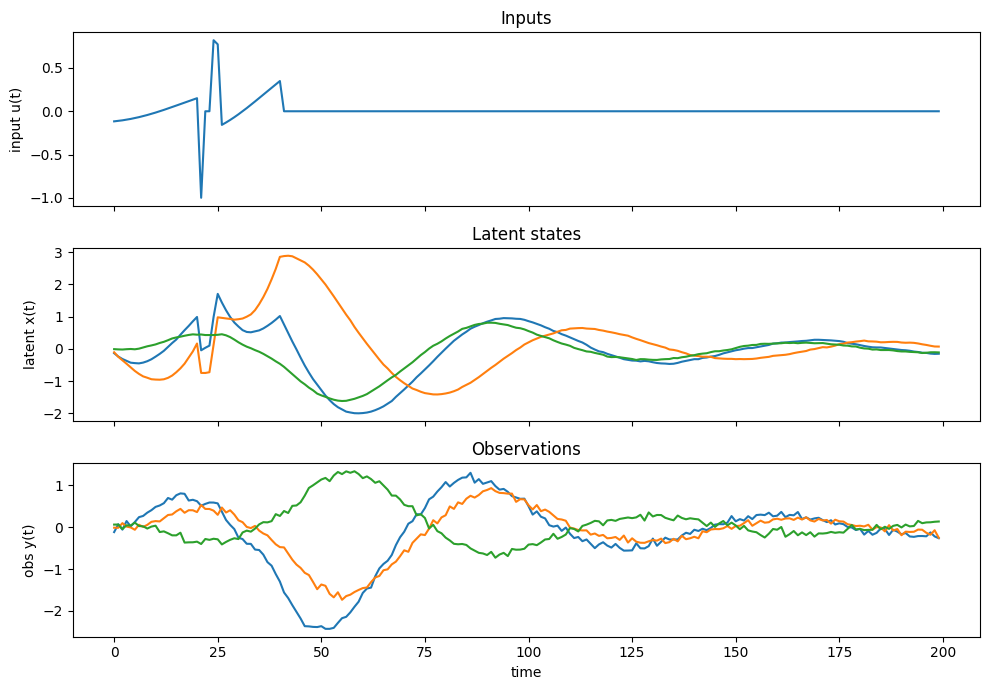

In [330]:
angle = 5 / 180 * np.pi
A = np.array([[np.cos(angle)*0.98, -np.sin(angle)*0.98, 0],
              [np.sin(angle)*0.98, np.cos(angle)*0.98, 0],
              [0.1, -0.1, 0.8]])
B = np.array([[1], [1], [0]])
C = np.array([[1, -1, 0], [0, 0, 1], [0.1, -0.098, -1]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
waypoints = {(20, 0): 1, (25, 1): 1, (23, 2): 1, (40, 0): 1}
x_noise = np.random.normal(0, 0.01, (200, 3))
y_noise = np.random.normal(0, 0.05, (200, 3))
states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C, latents=waypoints, x_noise=x_noise, y_noise=y_noise, maxu=1.0)

plot_input_latent_observation(inputs, states, observations)
plt.show()

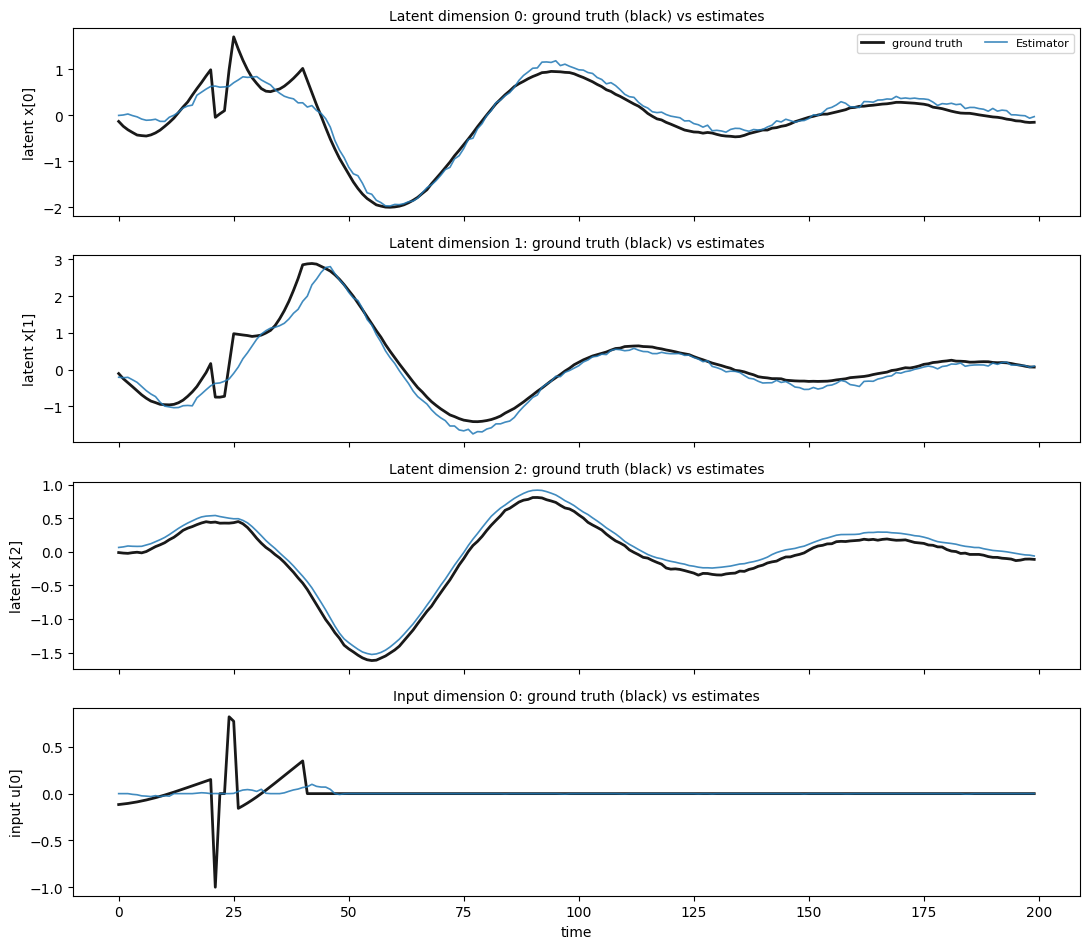

In [331]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 2 - null-space injection and hold

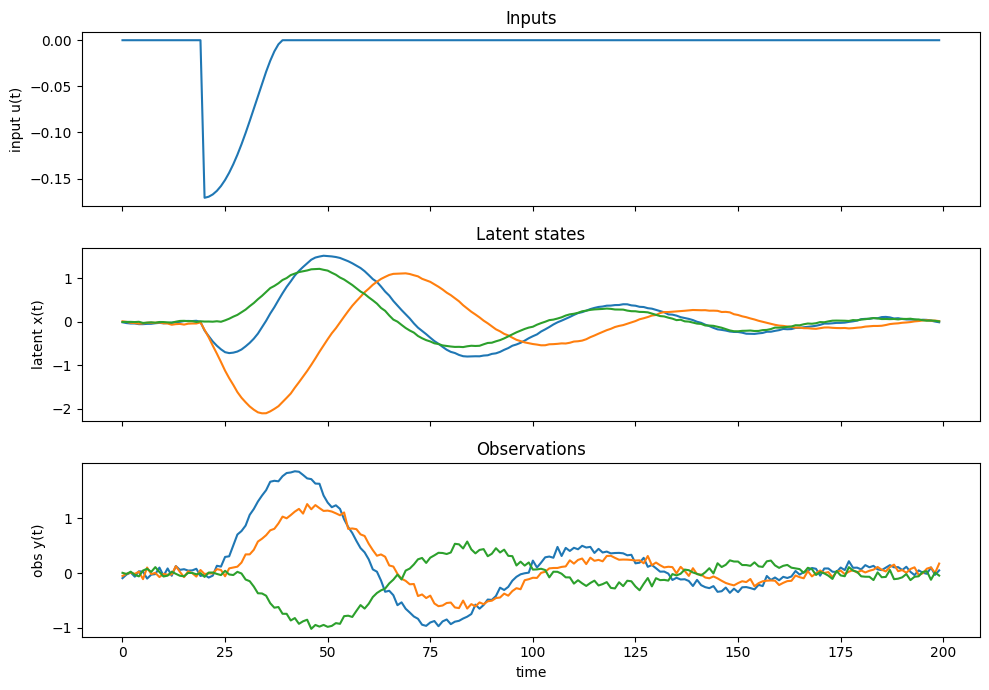

In [332]:
angle = 5 / 180 * np.pi
A = np.array([[np.cos(angle)*0.98, -np.sin(angle)*0.98, 0],
              [np.sin(angle)*0.98, np.cos(angle)*0.98, 0],
              [0.1, -0.1, 0.8]])
B = np.array([[1], [1], [0]])
C = np.array([[1, -1, 0], [0, 0, 1], [0.1, -0.098, -1]]); C /= np.linalg.norm(C, axis=1, keepdims=True)
waypoints = {}
for t in range(0, 20): waypoints[(t, 0)] = 0
for t in range(40, 60): waypoints[(t, 2)] = 1
x_noise = np.random.normal(0, 0.01, (200, 3))
y_noise = np.random.normal(0, 0.05, (200, 3))
states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C, latents=waypoints, x_noise=x_noise, y_noise=y_noise, maxu=1.0)

plot_input_latent_observation(inputs, states, observations)
plt.show()

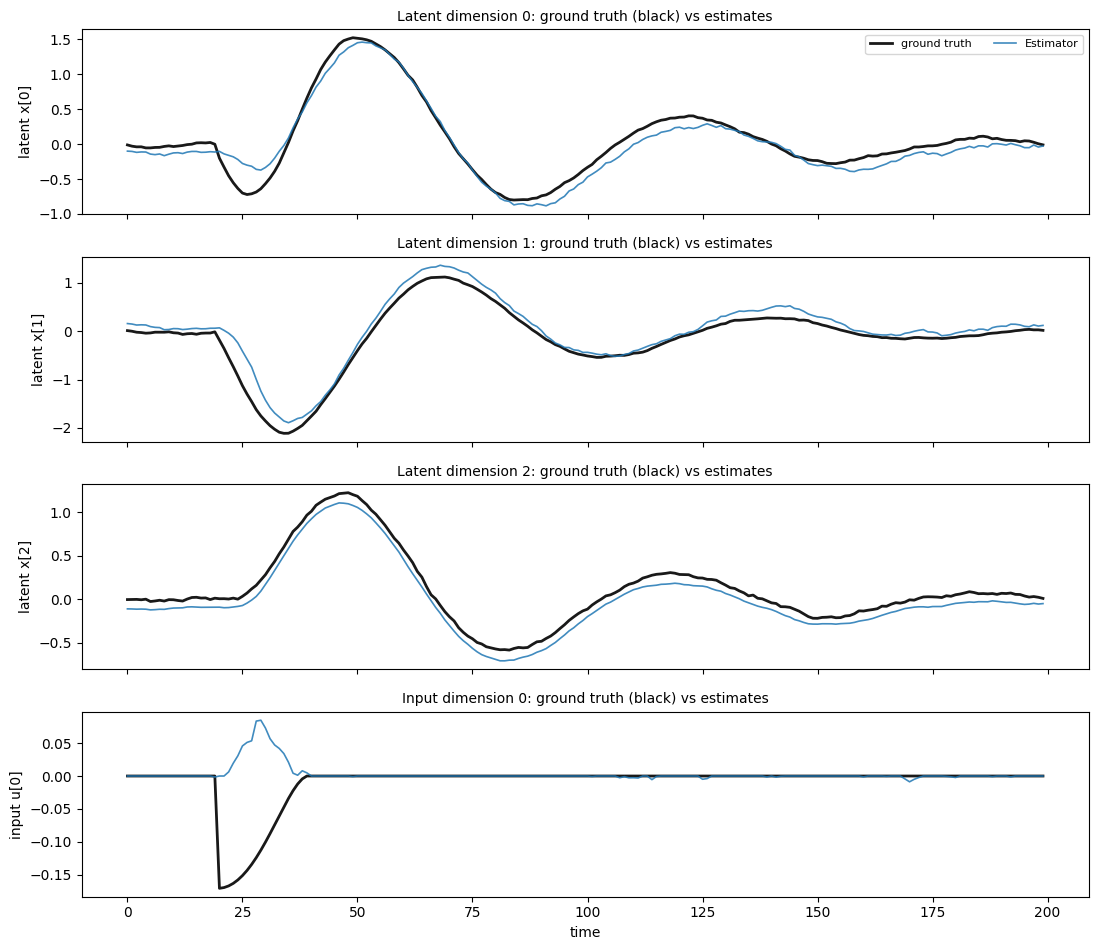

In [333]:
results = run_estimator(observations, latent_dim=3, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 3 - use non-normality

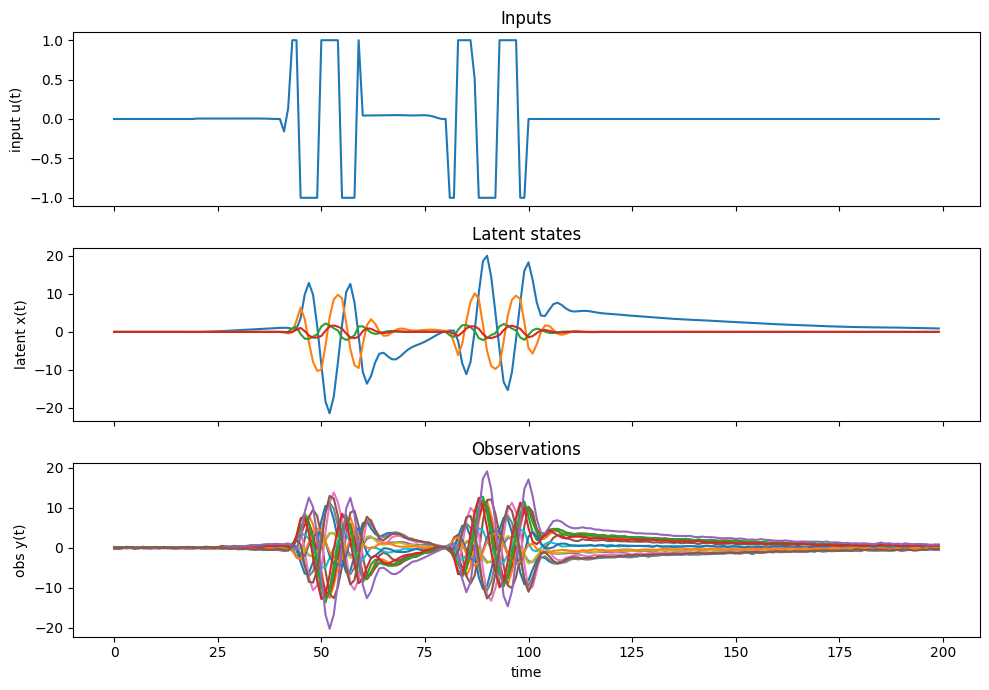

In [334]:
angle = 50 / 180 * np.pi
A = np.array([[0.98, 1, 0, 0],
              [0, 0.8, 3, 0],
              [0, 0, 0.75*np.cos(angle), -0.75*np.sin(angle)],
              [0, 0, 0.75*np.sin(angle), 0.75*np.cos(angle)]])
B = np.array([[0.1], [0.1], [0.9], [0]])
C = np.random.normal(0, 1, (16, 4)); C[:, 0] += 0.2; C[:, 1] += 0.1
C /= np.linalg.norm(C, axis=1, keepdims=True)
waypoints = {}
for t in range(0, 20): waypoints[(t, 0)] = 0
for t in range(40, 60): waypoints[(t, 0)] = 1
for t in range(80, 100): waypoints[(t, 0)] = 0
x_noise = np.random.normal(0, 0.001, (200, 4))
y_noise = np.random.normal(0, 0.1, (200, 16))
states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C, latents=waypoints, x_noise=x_noise, y_noise=y_noise, maxu=1.0)

plot_input_latent_observation(inputs, states, observations)
plt.show()

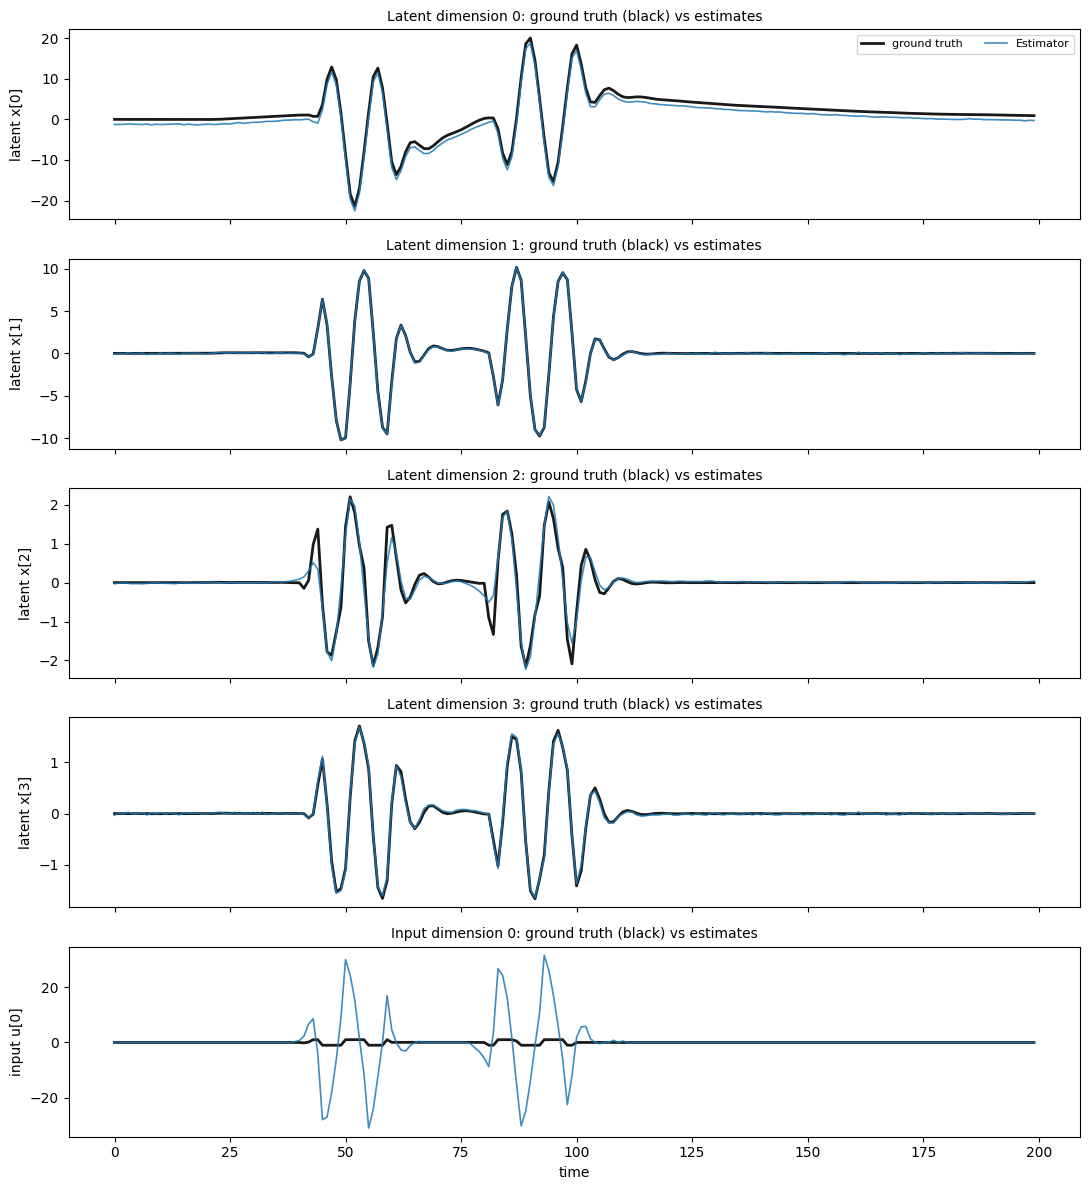

In [335]:
results = run_estimator(observations, latent_dim=4, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()

### Case 4 - use non-normality

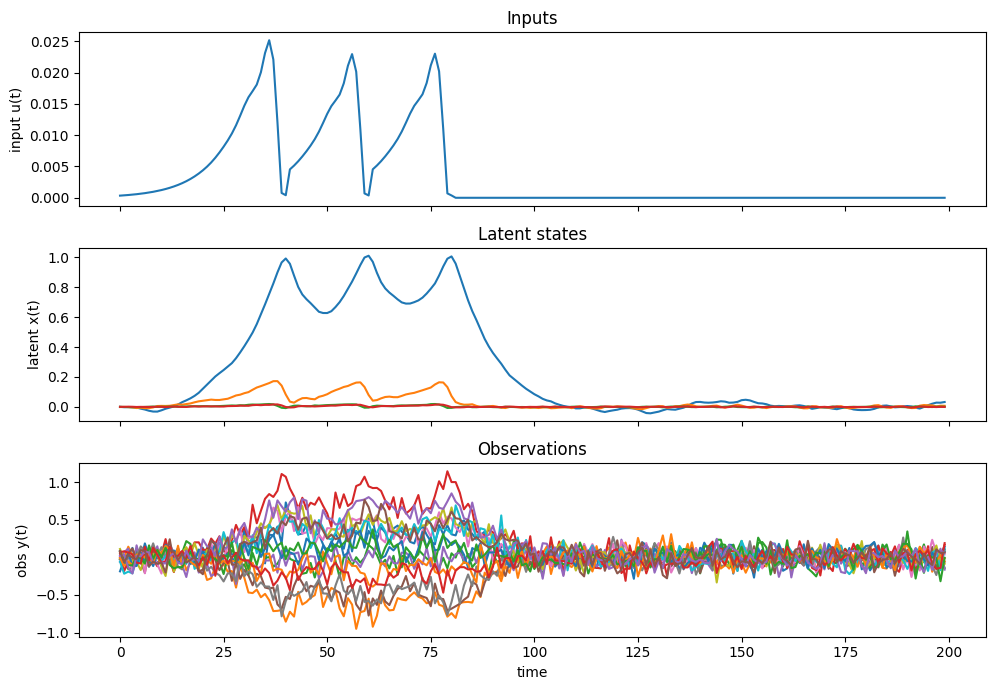

In [336]:
angle = 60 / 180 * np.pi
A = np.array([[0.88, 1, 0, 0],
              [0, 0.7, 3, 0],
              [0, 0, 0.65*np.cos(angle), -0.65*np.sin(angle)],
              [0, 0, 0.65*np.sin(angle), 0.65*np.cos(angle)]])
B = np.array([[0.1], [0.1], [0.9], [0]])
C = np.random.normal(0, 1, (16, 4)); C[:, 0] += 0.2; C[:, 1] += 0.1
C /= np.linalg.norm(C, axis=1, keepdims=True)
waypoints = {(40, 0): 1, (60, 0): 1, (80, 0): 1}
x_noise = np.random.normal(0, 0.001, (200, 4))
y_noise = np.random.normal(0, 0.1, (200, 16))
states, observations, inputs, noiseless_states = simulate_from_latents(
    A, B, C, latents=waypoints, x_noise=x_noise, y_noise=y_noise, maxu=1.0)

plot_input_latent_observation(inputs, states, observations)
plt.show()

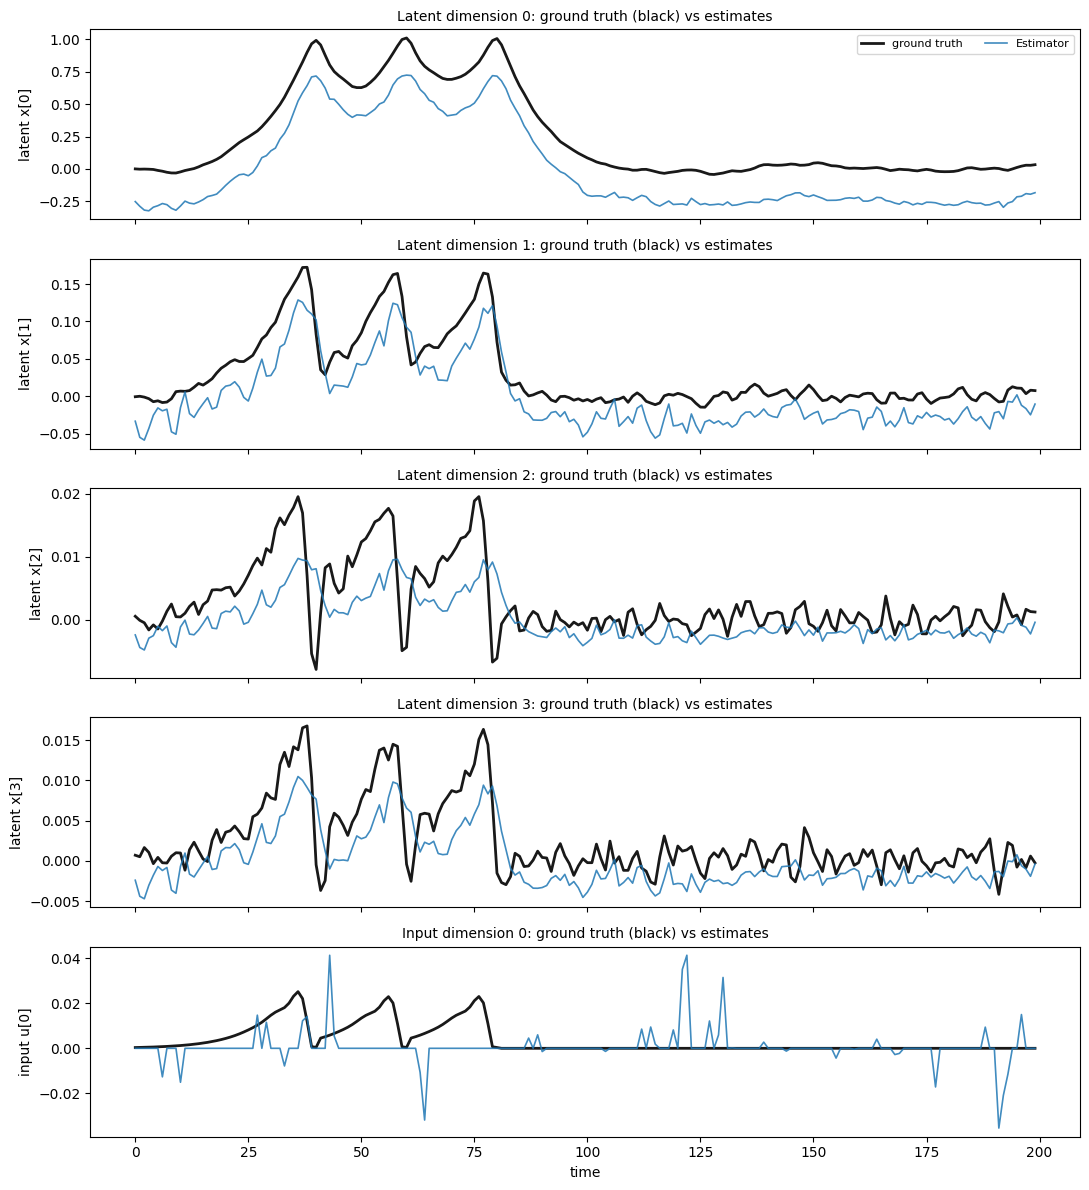

In [337]:
results = run_estimator(observations, latent_dim=4, input_dim=1)
plot_input_latent_comparison(inputs, states, results, align_inputs=False, align_latents=True, active={})
plt.show()